Prédiction de la probabilité de "stress hydrique", le stress hydrique étant considéré ici comme se référant à l'appartenance à la classe "iC-APEX < 0.5", et de l'incertitude associée.

Covariables attendues :
- Raster d'altitude
- Raster de réserve utile (catégoriel)
- Raster de CWB semaine par semaine (le modèle chosira en fonction de la semaine ciblée)
- Données Siclima en csv

Variable cible :
- Valeur continue 0 < p < 1 : probabilité de présence pour chaque classe (iC-apex < 0.5 et iC-apex > 0.5)

Le modèle utilise la loss DeepMaxent, AUC-ROC et Accuracy sont calculées comme métriques d'évaluation. Le split est fait par blocs spatiaux et utilise la méthode Leave-One-Block-Out. L'incertitude associée est prédite parallèlement avec la méthode MC-Dropout. Optuna calcule les meilleurs hyperparamètres avant entraînement.

# 0. IMPORTS

In [1]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Core libraries
import numpy as np
import pandas as pd
import glob
import os
from tqdm import tqdm
import verde as vd

# Geospatial libraries
import rasterio
from rasterio.windows import from_bounds
from rasterio.plot import show
from rasterio.mask import mask as rasterio_mask
import geopandas as gpd
from shapely.geometry import box
from shapely.geometry import Point
from rasterio.transform import from_origin

# Machine Learning
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import roc_auc_score, accuracy_score, log_loss
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)  # évite le spam de logs
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import copy

import sys
sys.path.append("C:/Users/juillact/Documents/deep-ApexVigne")

from src.model import (
    mlp_model,
    deepmaxent_model,
    predict_with_uncertainty,
    make_predictions,
    save_mlp_model,
    load_mlp_model
)
from src.losses import deepmaxent_loss
from src.losses import ce_loss

# Additional imports for training
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import copy

# Visualization
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.patch import geos_to_path

# Other
from datetime import datetime, timedelta
from shapely.ops import unary_union

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


# 1. LOAD APEX-VIGNE DATASET

In [2]:
# Load the apex-vigne dataset
df = pd.read_csv('data/data_irrig_cep.csv', encoding='latin1', low_memory=False)

print(f"📊 Dataset shape: {df.shape[0]:,} observations × {df.shape[1]} columns")
print(f"\n🔤 Available columns:\n{df.columns.tolist()[:15]}...")

# Display first few rows
df.head(3)

📊 Dataset shape: 46,403 observations × 22 columns

🔤 Available columns:
['id_session', 'date_creation', 'date_maj', 'date_session', 'apex0', 'apex1', 'apex2', 'id_observateur', 'id_parcelle', 'id_stade', 'commentaire', 'device_hardware', 'device_software', 'longitude', 'latitude']...


,id_session,date_creation,date_maj,date_session,apex0,apex1,apex2,id_observateur,id_parcelle,id_stade,...,device_software,longitude,latitude,location,en_parcelle,est_archivee,raison_archive,app_version,irriguee,cepage
0,00020b39-e765-4337-999a-63e1f59aca46,2025-08-19T13:43:38Z,2025-08-19T13:43:38Z,2025-07-24,4,37,9,4e5e6f16-d26c-428e-a387-007533fa7be9,5843944e-d9d2-48cc-95c8-8d639807b031,NaN,...,iOS 18.5,6.132792,45.550099,,1.0,0,NaN,6.2.0,0.0,abouriou
1,00041c61510442e5a64fb3af8ce11e24,2024-05-02T12:16:41Z,2025-04-18T08:46:16Z,2024-05-02,35,15,2,70c659af882b42ffb6b9415995434669,2f635c3720504254aebd2687712b0c8b,st-H-57-57,...,iOS 17.4.1,3.544615,43.533837,,1.0,0,NaN,NaN,NaN,NaN
2,0007ba68-e4f1-3fbd-82a9-336c7718bb2a,2020-06-25T04:27:02Z,2025-04-18T08:45:29Z,2019-07-10,13,31,6,edb6d513-eb76-4ad0-ae8a-0be7770048eb,5241d050-de2c-d5e5-a9f7-59f03c2e12ea,NaN,...,Android 11,NaN,NaN,,0.0,0,NaN,NaN,NaN,NaN


In [3]:
date_debut_str = "2025-08-11"

In [4]:
# Parameters
date_debut_str = "2025-07-21"


In [5]:
#Filtrer les observations par date
date_debut = pd.to_datetime(date_debut_str)
date_fin = date_debut + pd.Timedelta(days=6)
date_fin_str = date_fin.strftime("%Y-%m-%d")

# Filtrage temporel
df['date_session'] = pd.to_datetime(df['date_session'], errors='coerce')
df_filtered = df[(df['date_session'] >= date_debut_str) & (df['date_session'] <= date_fin_str)]

print(f"📅 Période sélectionnée : {date_debut_str} → {date_fin_str}")
print(f"📊 Observations totales  : {len(df):,}")
print(f"📊 Après filtrage        : {len(df_filtered):,} ({len(df_filtered)/len(df)*100:.1f}%)")
print(f"\n📋 Période couverte par les données filtrées :")
print(f"   De : {df_filtered['date_session'].min().date()}")
print(f"   À  : {df_filtered['date_session'].max().date()}")

📅 Période sélectionnée : 2025-07-21 → 2025-07-27
📊 Observations totales  : 46,403
📊 Après filtrage        : 1,137 (2.5%)

📋 Période couverte par les données filtrées :
   De : 2025-07-21
   À  : 2025-07-27


In [6]:
# Conversion en objet spatial
df_filtered_sf = (df_filtered
    .assign(
        longitude = pd.to_numeric(df['longitude'].replace("NULL", pd.NA), errors='coerce'),
        latitude  = pd.to_numeric(df['latitude'].replace("NULL", pd.NA),  errors='coerce')
    )
    .dropna(subset=['longitude', 'latitude'])
    .pipe(lambda d: gpd.GeoDataFrame(
        d,
        geometry=gpd.points_from_xy(d['longitude'], d['latitude']),
        crs="EPSG:4326"
    ))
)

In [7]:
# Filtrer les observations dans la zone d'étude
study_zone = gpd.read_file("data/study_zone_viti.gpkg")
df_filtered_sf_proj = df_filtered_sf.to_crs(study_zone.crs)
df_zone = gpd.sjoin(df_filtered_sf_proj, study_zone, how="inner", predicate="within").copy()

# Jointure spatiale observations → mailles SAFRAN pour récupérer l'identifiant 'cell'
coords_safran = pd.read_csv("data/cov/coordonnees_mailles_safran.csv", sep=";")
coords_safran_gdf = gpd.GeoDataFrame(
    coords_safran,
    geometry=gpd.points_from_xy(coords_safran["longitude"], coords_safran["latitude"]),
    crs="EPSG:4326"
).to_crs(study_zone.crs)

# Pour chaque observation, on cherche la maille SAFRAN la plus proche
from shapely.ops import nearest_points
def find_nearest_cell(geom, safran_gdf):
    distances = safran_gdf.geometry.distance(geom)
    return safran_gdf.iloc[distances.idxmin()]["cell"]

df_zone["cell"] = df_zone.geometry.apply(
    lambda g: find_nearest_cell(g, coords_safran_gdf)
)

print(f"✅ Colonne 'cell' ajoutée à df_zone — {df_zone['cell'].nunique()} mailles SAFRAN distinctes")

print(f"📊 Avant filtre zone : {len(df_filtered_sf_proj):,} observations")
print(f"📊 Après filtre zone : {len(df_zone):,} observations")
print(f"   Soit {len(df_zone)/len(df_filtered_sf_proj)*100:.1f}% des observations retenues")

✅ Colonne 'cell' ajoutée à df_zone — 71 mailles SAFRAN distinctes
📊 Avant filtre zone : 1,136 observations
📊 Après filtre zone : 751 observations
   Soit 66.1% des observations retenues


In [8]:
# Calcul de l'iC-APEX
df_zone['ic_apex'] = (df_zone['apex0'] + 0.5 * df_zone['apex1']) / (
    df_zone['apex0'] + df_zone['apex1'] + df_zone['apex2']
)

# 2. DATA VISUALISATION

In [9]:
# 0. Chargement de la study_zone globale
study_zone_bg = gpd.read_file("data/study_zone.gpkg")
study_zone_bg_wgs = study_zone_bg.to_crs("EPSG:4326")

In [10]:
# fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# # Reprojection en WGS84 pour affichage cohérent
# study_zone_wgs = study_zone.to_crs("EPSG:4326")
# df_zone_wgs  = df_zone.to_crs("EPSG:4326")

# # Coord villes pour visualisation
# villes_data = {
#     "Nom": [
#         "Perpignan",   # PO
#         "Carcassonne",  # Aude
#         "Montpellier",  # Hérault
#         "Nîmes",        # Gard
#         "Avignon",        # Vaucluse
#         "Toulon",       # Var
#         "Marseille",    # BdR (Bouches-du-Rhône)
#         "Privas",       # Ardèche
#         "Valence"       # Drôme
#     ],
#     "Longitude": [2.8956, 2.3522, 3.8767, 4.3601, 4.81667, 5.9306, 5.3698, 4.5980, 4.8924],
#     "Latitude": [42.6986, 43.2122, 43.6110, 43.8367, 43.950001, 43.1242, 43.2965, 44.7351, 44.9334],
#     "Code_insee": ["66", "11", "34", "30", "84", "83", "13", "07", "26"]
# }
# df_villes = pd.DataFrame(villes_data)
# geometry = [Point(xy) for xy in zip(df_villes["Longitude"], df_villes["Latitude"])]
# villes_gdf = gpd.GeoDataFrame(df_villes, geometry=geometry, crs="EPSG:4326")

# # Affichage des 9 préfectures
# villes_gdf.plot(ax=ax, color="black", markersize=60, marker=".", edgecolor="black", linewidth=0.1, label="Préfectures")

# # Ajout des étiquettes de texte (noms des villes)
# for x, y, label in zip(villes_gdf.geometry.x, villes_gdf.geometry.y, villes_gdf["Nom"]):
#     ax.annotate(
#         label, 
#         xy=(x, y), 
#         xytext=(3, 3),
#         textcoords="offset points", 
#         fontsize=7, 
#         weight="normal",
#         color="#2c3e50"
#     )
    
# # Contour de la zone d'étude
# study_zone_wgs.plot(
#     ax=ax,
#     facecolor='lightgrey',
#     edgecolor='black',
#     linewidth=1.5,
#     alpha=0.3
# )

# # Contours study_zone complète
# study_zone_bg_wgs.plot(
#     ax=ax,
#     facecolor="none",
#     edgecolor="grey",
#     linewidth=1.2,
#     linestyle="--",
#     alpha=0.6,
# )

# # Points colorés par iG-APEX
# df_zone_wgs.plot(
#     ax=ax,
#     column='ic_apex',
#     cmap='RdYlGn',
#     markersize=15,
#     alpha=0.7,
#     legend=True,
#     legend_kwds={'label': 'iG-APEX', 'shrink': 0.6}
# )

# # Légende commune
# legend_elements = [
#     Line2D(
#         [0],
#         [0],
#         color="grey",
#         linewidth=1.2,
#         linestyle="--",
#         label="Zone d'étude globale",
#     ),
#     Line2D(
#         [0],
#         [0],
#         color="black",
#         linewidth=1.5,
#         linestyle="-",
#         label="Régions viticoles",
#     ),
# ]

# ax.set_title(
#     f"Distribution de l'iG-APEX — {date_debut_str} → {date_fin_str}\n"
#     f"({len(df_zone_wgs):,} observations)",
#     fontsize=13, fontweight='bold'
# )
# ax.set_xlabel('Longitude')
# ax.set_ylabel('Latitude')
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.legend(handles=legend_elements, fontsize=9, loc="lower right")

# plt.tight_layout()
# plt.show()

# 3. LOAD STUDY ZONE (GRID)

In [11]:
grid = gpd.read_file("data/study_zone_viti_grid.gpkg")
print(f"📐 Cellules de grille totales         : {grid.shape[0]:,}")

📐 Cellules de grille totales         : 36,377


# 4. RASTERS

In [12]:
from datetime import datetime, timedelta
import glob
import rasterio
import numpy as np

# --- 1. Configuration des dates pour le CWB ---
# Assure-toi que date_debut_str est bien définie plus haut (ex: "2025-07-20")
date_debut = datetime.strptime(date_debut_str, "%Y-%m-%d")
date_cwb = date_debut - timedelta(days=1)
date_cwb_str = date_cwb.strftime("%Y-%m-%d") 

# --- 2. Construction dynamique des chemins des fichiers ---
# Chemins pour l'altitude (alt) et la réserve utile (ru)
subfolders = ['alt', 'ru', 'pente', 'exp']
raster_files = []
for sub in subfolders:
    files = sorted(glob.glob(f'data/cov/rasters/{sub}/*.tif'))
    raster_files.extend(files)

# # Chemin dynamique pour le CWB basé sur la date calculée
# cwb_raster_path = f"data/cov/rasters/cwb/CWB_1km_{date_cwb_str}.tif"
# cwb_file = glob.glob(cwb_raster_path)

# if not cwb_file:
#     print(f"⚠️ Attention : Le raster CWB pour la date {date_cwb_str} est introuvable à l'adresse {cwb_raster_path}")
# else:
#     raster_files.extend(cwb_file)

# --- Chemin dynamique pour la pluie cumulée basé sur la même date que le CWB (date_debut - 1) ---
pluvio_raster_path = f"data/cov/rasters/pluvio/PLUIE_CUM_1km_{date_cwb_str}.tif"
pluvio_file = glob.glob(pluvio_raster_path)

if not pluvio_file:
    print(f"⚠️ Attention : Le raster de pluie cumulée pour la date {date_cwb_str} est introuvable à l'adresse {pluvio_raster_path}")
else:
    raster_files.extend(pluvio_file)

# --- 3. Fonction d'extraction spatiale (Rasterio) ---
def extract_raster_value(gdf, raster_path):
    with rasterio.open(raster_path) as src:
        # Repérage du centre de chaque cellule géométrique
        centroids = gdf.geometry.centroid
        coords = [(c.x, c.y) for c in centroids]
        
        # Échantillonnage de la valeur du pixel sous le centroïde
        sampled_values = [v[0] for v in src.sample(coords)]
        
        # Gestion des valeurs de NoData du raster
        if src.nodata is not None:
            sampled_values = [np.nan if v == src.nodata else v for v in sampled_values]
            
    return sampled_values

for f in raster_files:
    with rasterio.open(f) as src:
        res = abs(src.transform[0])
        print(f"   {f}")
        print(f"      Dimensions : {src.width} × {src.height} pixels")
        print(f"      Résolution : {res:.0f} m\n")

   data/cov/rasters/alt\altitude_study_zone.tif
      Dimensions : 424 × 337 pixels
      Résolution : 1000 m

   data/cov/rasters/ru\ru_raster.tif
      Dimensions : 425 × 336 pixels
      Résolution : 1000 m

   data/cov/rasters/pente\slope.tif
      Dimensions : 409 × 335 pixels
      Résolution : 1000 m

   data/cov/rasters/exp\exposure.tif
      Dimensions : 409 × 335 pixels
      Résolution : 1000 m

   data/cov/rasters/pluvio/PLUIE_CUM_1km_2025-07-20.tif
      Dimensions : 432 × 371 pixels
      Résolution : 992 m



# 5. VISUALISATION OF COVARIABLES

In [13]:
# import os
# import numpy as np
# import matplotlib.pyplot as plt
# import rasterio
# from rasterio.mask import mask as rasterio_mask
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature

# # --- 1. Reprojection en degrés des couches vectorielles ---
# study_zone_wgs84    = study_zone.to_crs("EPSG:4326")
# study_zone_bg_wgs84 = study_zone_bg.to_crs("EPSG:4326")
# minx, miny, maxx, maxy = study_zone_wgs84.total_bounds
# geoms = [study_zone.union_all()]

# # --- 2. Configuration de la figure (Une seule carte) ---
# plt.close('all')
# fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# # Sécurité : Vérifier si le fichier existe
# if not os.path.exists(pluvio_raster_path):
#     ax.set_title("Précipitations\n(Fichier introuvable)", fontsize=12, color='red', fontweight='bold')
#     ax.axis('off')
# else:
#     with rasterio.open(pluvio_raster_path) as src:
#         out_image, out_transform = rasterio_mask(src, geoms, crop=True, nodata=np.nan)
#         data = out_image[0].astype(np.float32)
        
#         img_height, img_width = data.shape
#         left, bottom = out_transform * (0, img_height)
#         right, top = out_transform * (img_width, 0)
#         extent = [left, right, bottom, top]  # Emprise dans le CRS natif (EPSG:2154)
        
#         nodata = src.nodata

#     # Masquage des valeurs NoData / invalides
#     if nodata is not None:
#         data = np.ma.masked_where((data == nodata) | np.isnan(data) | ~np.isfinite(data), data)
#     else:
#         data = np.ma.masked_where((data <= -9999) | (data == 0) | np.isnan(data) | ~np.isfinite(data), data)
    
#     ax.set_facecolor('none')
#     ax.set_extent([minx, maxx, miny, maxy], crs=ccrs.PlateCarree())
    
#     # Tracé du raster (Lambert 93 reprojeté à la volée par Cartopy)
#     im = ax.imshow(data, extent=extent, origin='upper', cmap='YlGnBu', transform=ccrs.epsg(2154))
    
#     # Couches vectorielles
#     study_zone_wgs84.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1, transform=ccrs.PlateCarree())
#     study_zone_bg_wgs84.plot(ax=ax, facecolor="none", edgecolor="grey", linewidth=1.2, linestyle="--", alpha=0.6, transform=ccrs.PlateCarree())
    
#     # Fonds de carte Cartopy
#     ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
#     ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle='--')
    
#     # Légende (Colorbar)
#     cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.04)
#     cbar.set_label('Cumul (mm)', fontsize=10)
    
#     # Grille et coordonnées
#     gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, linestyle='--')
#     gl.top_labels = False
#     gl.right_labels = False
    
#     ax.set_title('Précipitations', fontsize=12, fontweight='bold')

# plt.tight_layout()
# plt.show()

In [14]:
# # --- 1. Configuration Réserve Utile ---
# ru_labels = {1: "< 50 mm", 2: "50-100 mm", 3: "100-150 mm", 4: "150 - 200 mm", 5: "> 200 mm", 9: "non sols"}
# ru_colors = ['#d73027', '#f46d43', '#fdae61', '#abd9e9', '#4575b4', '#999999']
# ru_cmap = ListedColormap(ru_colors)
# ru_bounds = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 9.5] 
# ru_norm = BoundaryNorm(ru_bounds, ru_cmap.N)
# geoms = [study_zone.union_all()]

# # --- 2. Reprojection en degrés des couches vectorielles ---
# study_zone_wgs84    = study_zone.to_crs("EPSG:4326")
# study_zone_bg_wgs84 = study_zone_bg.to_crs("EPSG:4326")
# minx, miny, maxx, maxy = study_zone_wgs84.total_bounds

# # --- 3. Définition des variables à afficher ---
# # On passe à 6 variables en incluant la CWB et la pluie cumulée
# variables_to_plot = [
#     ('data/cov/rasters/alt/altitude_study_zone.tif', 'Altitude', 'Altitude (m)', 'terrain', None, None),
#     ('data/cov/rasters/ru/ru_raster.tif', 'Réserve utile', 'Classe', ru_cmap, ru_norm, ru_labels),
#     (pluvio_raster_path, 'Précipitations', 'Cumul (mm)', 'YlGnBu', None, None),
#     ('data/cov/rasters/pente/slope.tif', 'Pente', 'Degrés (°)', 'YlOrRd', None, None),
#     ('data/cov/rasters/exp/exposure.tif', 'Exposition', 'Degrés (°)', 'twilight_shifted', None, None)
# ]

# # --- 4. Tracé des graphiques ---
# # 2 lignes x 3 colonnes, toutes les cases sont maintenant utilisées
# fig, axes = plt.subplots(2, 3, figsize=(24, 14), subplot_kw={'projection': ccrs.PlateCarree()})
# axes_flat = axes.flatten()
# for ax, (filepath, title, unit, cmap, norm, labels) in zip(axes_flat, variables_to_plot):
    
#     # Sécurité : Vérifier si le fichier existe avant d'essayer de l'ouvrir
#     if not os.path.exists(filepath):
#         ax.set_title(f"{title}\n(Fichier introuvable)", fontsize=12, color='red', fontweight='bold')
#         ax.axis('off')
#         continue
#     with rasterio.open(filepath) as src:
#         out_image, out_transform = rasterio_mask(src, geoms, crop=True, nodata=np.nan)
#         data = out_image[0].astype(np.float32)
        
#         img_height, img_width = data.shape
#         left, bottom = out_transform * (0, img_height)
#         right, top = out_transform * (img_width, 0)
#         extent = [left, right, bottom, top]  # emprise dans le CRS natif du raster (EPSG:2154)
        
#         nodata = src.nodata
#     if nodata is not None:
#         data = np.ma.masked_where((data == nodata) | np.isnan(data) | ~np.isfinite(data), data)
#     else:
#         data = np.ma.masked_where((data <= -9999) | (data == 0) | np.isnan(data) | ~np.isfinite(data), data)
#     ax.set_facecolor('none')
#     ax.set_extent([minx, maxx, miny, maxy], crs=ccrs.PlateCarree())
    
#     # Le raster reste en Lambert 93 en interne : cartopy reprojette à la volée pour l'affichage
#     im = ax.imshow(data, extent=extent, origin='upper', cmap=cmap, norm=norm,
#                    transform=ccrs.epsg(2154))
    
#     study_zone_wgs84.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1, transform=ccrs.PlateCarree())
#     study_zone_bg_wgs84.plot(ax=ax, facecolor="none", edgecolor="grey", linewidth=1.2, linestyle="--", alpha=0.6, transform=ccrs.PlateCarree())
    
#     ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
#     ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle='--')
#     # Gestion des légendes
#     if labels is None:
#         cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.04)
#         cbar.set_label(unit, fontsize=10)
#     else:
#         legend_patches = [
#             mpatches.Patch(color=ru_colors[i], label=labels[val])
#             for i, val in enumerate([1, 2, 3, 4, 5, 9])
#         ]
#         ax.legend(handles=legend_patches, title=unit, loc='upper left', 
#                   frameon=True, facecolor='white', edgecolor='none', fontsize=9)
#     gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, linestyle='--')
#     gl.top_labels = False
#     gl.right_labels = False
#     ax.set_title(title, fontsize=12, fontweight='bold')
# plt.suptitle('Covariables environnementales', fontsize=14, fontweight='bold', y=1.02)
# plt.tight_layout()
# plt.show()

In [15]:
# # --- 3. Définition des variables à afficher ---
# # Uniquement les 3 variables topographiques
# variables_to_plot = [
#     ('data/cov/rasters/alt/altitude_study_zone.tif', 'Altitude', 'Altitude (m)', 'terrain', None, None),
#     ('data/cov/rasters/pente/slope.tif', 'Pente', 'Degrés (°)', 'YlOrRd', None, None),
#     ('data/cov/rasters/exp/exposure.tif', 'Exposition', 'Degrés (°)', 'twilight_shifted', None, None)
# ]

# # --- 4. Tracé des graphiques ---
# # 1 ligne x 3 colonnes
# fig, axes = plt.subplots(1, 3, figsize=(24, 8), subplot_kw={'projection': ccrs.epsg(2154)})
# axes_flat = axes.flatten()

# for ax, (filepath, title, unit, cmap, norm, labels) in zip(axes_flat, variables_to_plot):
    
#     # Sécurité : Vérifier si le fichier existe avant d'essayer de l'ouvrir
#     if not os.path.exists(filepath):
#         ax.set_title(f"{title}\n(Fichier introuvable)", fontsize=12, color='red', fontweight='bold')
#         ax.axis('off')
#         continue
#     with rasterio.open(filepath) as src:
#         out_image, out_transform = rasterio_mask(src, geoms, crop=True, nodata=np.nan)
#         data = out_image[0].astype(np.float32)
        
#         img_height, img_width = data.shape
#         left, bottom = out_transform * (0, img_height)
#         right, top = out_transform * (img_width, 0)
#         extent = [left, right, bottom, top]
        
#         nodata = src.nodata
#     if nodata is not None:
#         data = np.ma.masked_where((data == nodata) | np.isnan(data) | ~np.isfinite(data), data)
#     else:
#         data = np.ma.masked_where((data <= -9999) | (data == 0) | np.isnan(data) | ~np.isfinite(data), data)
#     ax.set_facecolor('none')
#     ax.set_extent([study_zone.total_bounds[0], study_zone.total_bounds[2],
#                    study_zone.total_bounds[1], study_zone.total_bounds[3]], 
#                  crs=ccrs.epsg(2154))
#     im = ax.imshow(data, extent=extent, origin='upper', cmap=cmap, norm=norm,
#                    transform=ccrs.epsg(2154))
    
#     study_zone.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1, transform=ccrs.epsg(2154))
#     study_zone_bg.plot(ax=ax, facecolor="none", edgecolor="grey", linewidth=1.2, linestyle="--", alpha=0.6)
    
#     ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
#     ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle='--')
    
#     # Gestion des légendes (colorbar continue uniquement, plus de labels catégoriels ici)
#     cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.04)
#     cbar.set_label(unit, fontsize=10)
    
#     gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, linestyle='--')
#     gl.top_labels = False
#     gl.right_labels = False
#     ax.set_title(title, fontsize=12, fontweight='bold')

# plt.tight_layout()
# plt.show()

In [16]:
import rasterio

with rasterio.open(pluvio_raster_path) as src:
    print("CRS pluvio :", src.crs)

print("CRS study_zone :", study_zone.crs)

CRS pluvio : EPSG:2154
CRS study_zone : EPSG:2154


# 6. PREPARE TRAINING DATA

In [17]:
for i, raster in enumerate(raster_files, 1):
    with rasterio.open(raster) as src:
        raster_resolution = abs(src.transform[0])
        raster_transform = src.transform
        raster_crs = src.crs

        print(f"{i:2d}. {os.path.basename(raster)}. Résolution : {raster_resolution:.0f} m. CRS : {raster_crs}.")

 1. altitude_study_zone.tif. Résolution : 1000 m. CRS : EPSG:2154.
 2. ru_raster.tif. Résolution : 1000 m. CRS : EPSG:2154.
 3. slope.tif. Résolution : 1000 m. CRS : EPSG:2154.
 4. exposure.tif. Résolution : 1000 m. CRS : EPSG:2154.
 5. PLUIE_CUM_1km_2025-07-20.tif. Résolution : 992 m. CRS : EPSG:2154.


In [18]:
# Calcul de l'iC-APEX
df_zone = df_zone.copy()
df_zone['date_session'] = pd.to_datetime(df_zone['date_session']).dt.date
df_zone['ic_apex'] = (df_zone['apex0'] + df_zone['apex1'] * 0.5) / \
                       (df_zone['apex0'] + df_zone['apex1'] + df_zone['apex2'])

print(f"📍 Observations brutes      : {len(df):,}")
print(f"📍 Après nettoyage spatial  : {len(df_filtered_sf):,}")
print(f"📍 Dans la zone d'étude     : {len(df_zone):,}")
print(f"\n📋 Aperçu iG-APEX :")
print(df_zone['ic_apex'].describe().round(3))

📍 Observations brutes      : 46,403
📍 Après nettoyage spatial  : 1,136
📍 Dans la zone d'étude     : 751

📋 Aperçu iG-APEX :
count    751.000
mean       0.482
std        0.249
min        0.000
25%        0.300
50%        0.500
75%        0.660
max        1.000
Name: ic_apex, dtype: float64


In [19]:
# Coordonnées des centroïdes de la grille en Lambert
grid_proj = grid.to_crs("EPSG:2154")

# Jointure spatiale grid_proj → mailles SAFRAN pour récupérer l'identifiant 'cell'
coords_safran = pd.read_csv("data/cov/coordonnees_mailles_safran.csv", sep=";")
coords_safran_gdf = gpd.GeoDataFrame(
    coords_safran,
    geometry=gpd.points_from_xy(coords_safran["longitude"], coords_safran["latitude"]),
    crs="EPSG:4326"
).to_crs("EPSG:2154")

# Pour chaque cellule de la grille, on cherche la maille SAFRAN la plus proche
from sklearn.neighbors import BallTree
import numpy as np

# Coordonnées des centroïdes de la grille
grid_coords = np.array([
    (geom.centroid.x, geom.centroid.y) for geom in grid_proj.geometry
])

# Coordonnées des points SAFRAN
safran_coords = np.array([
    (geom.x, geom.y) for geom in coords_safran_gdf.geometry
])

# Recherche du point SAFRAN le plus proche pour chaque cellule
tree = BallTree(safran_coords, metric="euclidean")
indices = tree.query(grid_coords, k=1, return_distance=False).flatten()

grid_proj = grid_proj.copy()
grid_proj["cell"] = coords_safran_gdf.iloc[indices]["cell"].values

print(f"✅ Colonne 'cell' ajoutée à grid_proj — {grid_proj['cell'].nunique()} mailles SAFRAN distinctes")
print(grid_proj[["cell"]].head(3))


centroids = [(geom.centroid.x, geom.centroid.y) for geom in grid_proj.geometry]
num_cells = len(grid_proj)
num_variables = len(raster_files)

print(f"📍 Nombre de cellules : {num_cells:,}")
print(f"📁 Nombre de variables : {num_variables}")

# Tenseur X — valeurs environnementales
X_tensor = torch.zeros((num_cells, num_variables), dtype=torch.float32)

print("\n🌡️ Extraction des valeurs des covariables...")
for var_idx, filepath in enumerate(tqdm(raster_files, desc="Processing rasters")):
    with rasterio.open(filepath) as src:
        nodata = src.nodata
        values = np.array([val[0] for val in src.sample(centroids)], dtype=np.float32)
        if nodata is not None:
            values[values == nodata] = np.nan
        X_tensor[:, var_idx] = torch.tensor(values, dtype=torch.float32)

print(f"\n✅ Tenseur X créé !")

✅ Colonne 'cell' ajoutée à grid_proj — 638 mailles SAFRAN distinctes
   cell
0  9257
1  9257
2  9257


📍 Nombre de cellules : 36,377
📁 Nombre de variables : 5

🌡️ Extraction des valeurs des covariables...


Processing rasters:   0%|                                                                        | 0/5 [00:00<?, ?it/s]

Processing rasters:  20%|████████████▊                                                   | 1/5 [00:00<00:01,  2.28it/s]

Processing rasters:  40%|█████████████████████████▌                                      | 2/5 [00:00<00:01,  2.20it/s]

Processing rasters:  60%|██████████████████████████████████████▍                         | 3/5 [00:01<00:00,  2.18it/s]

Processing rasters:  80%|███████████████████████████████████████████████████▏            | 4/5 [00:01<00:00,  2.17it/s]

Processing rasters: 100%|████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.15it/s]

Processing rasters: 100%|████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.17it/s]


✅ Tenseur X créé !


In [20]:
import ast

# Chargement unique du CSV SICLIMA (une seule fois, pas dans la boucle !)
year = pd.to_datetime(date_debut_str).year
df_sic = pd.read_csv(f"data/cov/cov_siclima_{year}.csv", engine='python')
df_sic = df_sic.set_index("cell")  # indexation par cell pour accès rapide

# Indices des 3 variables de température dans le vecteur SICLIMA à 16 valeurs
# (ordre : dli_q, t_q, co2, drainc_q, pe_q, preliq_q, wg_racine_q,
#          tsup_h_q, tinf_h_q, etp_q, etppm, evap_q, hu_q, runc_q, swi_q, q_q)
IDX_T_MOY = 1   # t_q       : température moyenne
IDX_T_MAX = 7   # tsup_h_q  : température maximale
IDX_T_MIN = 8   # tinf_h_q  : température minimale
TEMP_INDICES = [IDX_T_MOY, IDX_T_MAX, IDX_T_MIN]
N_COV_SICLIMA = len(TEMP_INDICES)  # = 3

def load_siclima_vector(cell: int, date_obs: str) -> np.ndarray:
    if cell not in df_sic.index:
        return np.full(N_COV_SICLIMA, np.nan, dtype=np.float32)
    if date_obs not in df_sic.columns:
        return np.full(N_COV_SICLIMA, np.nan, dtype=np.float32)
    valeur = df_sic.loc[cell, date_obs]
    if isinstance(valeur, str):
        valeur = ast.literal_eval(valeur)
    valeur = np.array(valeur, dtype=np.float32)
    return valeur[TEMP_INDICES]  # ne garde que temp moy / max / min

print("🌿 Extraction des covariables SICLIMA (températures uniquement)...")
siclima_values = np.array([
    load_siclima_vector(cell=row["cell"], date_obs=date_debut_str)
    for _, row in tqdm(grid_proj.iterrows(), total=len(grid_proj), desc="SICLIMA")
], dtype=np.float32)

X_siclima = torch.tensor(siclima_values, dtype=torch.float32)
X_tensor = torch.cat([X_tensor, X_siclima], dim=1)
num_variables = X_tensor.shape[1]
print(f"✅ SICLIMA (temp) ajouté — X_tensor shape : {X_tensor.shape}")

🌿 Extraction des covariables SICLIMA (températures uniquement)...


SICLIMA:   0%|                                                                               | 0/36377 [00:00<?, ?it/s]

SICLIMA:   5%|██▉                                                              | 1665/36377 [00:00<00:02, 16629.52it/s]

SICLIMA:  10%|██████▍                                                          | 3621/36377 [00:00<00:01, 18298.07it/s]

SICLIMA:  15%|█████████▉                                                       | 5545/36377 [00:00<00:01, 18704.22it/s]

...

SICLIMA:  87%|███████████████████████████████████████████████████████▌        | 31562/36377 [00:01<00:00, 19787.26it/s]

SICLIMA:  92%|███████████████████████████████████████████████████████████     | 33592/36377 [00:01<00:00, 19826.89it/s]

SICLIMA:  98%|██████████████████████████████████████████████████████████████▋ | 35645/36377 [00:01<00:00, 19963.36it/s]

SICLIMA: 100%|████████████████████████████████████████████████████████████████| 36377/36377 [00:01<00:00, 19577.15it/s]

✅ SICLIMA (temp) ajouté — X_tensor shape : torch.Size([36377, 8])


In [21]:
# Index de la colonne RU dans all_raster_files
ru_idx = next(i for i, f in enumerate(raster_files) if 'ru' in f.lower())

# Valeurs RU brutes
ru_values = X_tensor[:, ru_idx].numpy()

# Classes attendues (9 = non-sol traité séparément)
ru_classes = [1, 2, 3, 4, 5, 9]

# One-hot encoding
ru_onehot = np.zeros((num_cells, len(ru_classes)), dtype=np.float32)
for j, cls in enumerate(ru_classes):
    ru_onehot[:, j] = (ru_values == cls).astype(np.float32)

# Remplacement de la colonne RU par les colonnes one-hot
X_np = X_tensor.numpy()
X_np_without_ru = np.delete(X_np, ru_idx, axis=1)
X_tensor = torch.tensor(
    np.concatenate([X_np_without_ru, ru_onehot], axis=1),
    dtype=torch.float32
)

# Mise à jour du nombre de variables
num_variables = X_tensor.shape[1]

print(f"✅ RU encodée en one-hot ({len(ru_classes)} classes) et tenseur X mis à jour")
print(f"   X (covariables) : {X_tensor.shape}")

✅ RU encodée en one-hot (6 classes) et tenseur X mis à jour
   X (covariables) : torch.Size([36377, 13])


In [22]:
# Seuil de binarisation iC-APEX
IC_APEX_THRESHOLD = 0.5  # >= seuil → présence (1), < seuil → absence (0)

# Tenseur y — iC-APEX binarisé par cellule de grille
print("\n🔢 Construction du tenseur y (présence/absence par case)...")
df_zone_proj = df_zone.to_crs("EPSG:2154")
grid_with_idx  = grid_proj.copy()
grid_with_idx['cell_idx'] = range(num_cells)

# Jointure spatiale observations -> cellules
joined = gpd.sjoin(df_zone_proj[['ic_apex', 'geometry']],
                   grid_with_idx[['cell_idx', 'geometry']],
                   how='left', predicate='within')

# Comptage des présences et absences par cellule
ic_counts = (
    joined.groupby('cell_idx')['ic_apex']
    .agg(
        n_presence=lambda x: (x >= IC_APEX_THRESHOLD).sum(),
        n_absence =lambda x: (x <  IC_APEX_THRESHOLD).sum(),
        mean_ic_apex='mean'          # ← valeur moyenne pour l'affichage
    )
    .dropna()
)

# Tenseur y — shape (num_cells, 2) : [n_presence, n_absence]
y_tensor = torch.zeros((num_cells, 2), dtype=torch.float32)
y_tensor[ic_counts.index, 0] = torch.tensor(ic_counts['n_presence'].values, dtype=torch.float32)
y_tensor[ic_counts.index, 1] = torch.tensor(ic_counts['n_absence'].values,  dtype=torch.float32)

# Masque — cellules observées uniquement (au moins 1 observation)
observed_mask = torch.zeros(num_cells, dtype=torch.bool)
observed_mask[ic_counts.index] = True          # ← ic_counts à la place de ic_binary

# Exclure les non-sols (RU == 9)
nonsoil_mask  = torch.tensor(ru_values == 9)
observed_mask = observed_mask & ~nonsoil_mask

# Stats sur les cellules observées
n_presence_total = y_tensor[observed_mask, 0].sum().item()
n_absence_total  = y_tensor[observed_mask, 1].sum().item()
n_obs_total      = n_presence_total + n_absence_total

print(f"\n✅ Tenseur y créé !")
print(f"   Seuil iC-APEX                     : {IC_APEX_THRESHOLD}")
print(f"   y shape                           : {y_tensor.shape}")
print(f"   Cellules observées                : {observed_mask.sum().item():,}")
print(f"   Observations totales              : {int(n_obs_total):,}")
print(f"   iC-APEX >= {IC_APEX_THRESHOLD}             : {int(n_presence_total):,}")
print(f"   iC-APEX < {IC_APEX_THRESHOLD}             : {int(n_absence_total):,}")
print(f"   Ratio iC-APEX >= {IC_APEX_THRESHOLD}                   : {n_presence_total / n_obs_total * 100:.1f}%")
print(f"   Cellules non-sol exclues          : {nonsoil_mask.sum().item():,}")
print(f"   Cellules masquées (non observées) : {(~observed_mask).sum().item():,} / {num_cells:,}")


🔢 Construction du tenseur y (présence/absence par case)...

✅ Tenseur y créé !
   Seuil iC-APEX                     : 0.5
   y shape                           : torch.Size([36377, 2])
   Cellules observées                : 229
   Observations totales              : 741
   iC-APEX >= 0.5             : 391
   iC-APEX < 0.5             : 350
   Ratio iC-APEX >= 0.5                   : 52.8%
   Cellules non-sol exclues          : 367
   Cellules masquées (non observées) : 36,148 / 36,377


In [23]:
igapex_full = torch.zeros(num_cells, dtype=torch.float32)
igapex_full[ic_counts.index] = torch.tensor(ic_counts['mean_ic_apex'].values, dtype=torch.float32)
igapex_full = igapex_full.numpy()

# Coordonnées des centroïdes de la grille, reprojetées en WGS84 pour l'affichage
grid_wgs = grid_proj.to_crs("EPSG:4326")
coords_full = np.column_stack([grid_wgs.geometry.centroid.x, grid_wgs.geometry.centroid.y])

## 7. DATA QUALITY CHECK

In [24]:
# Check for missing values
nan_mask = torch.isnan(X_tensor)
rows_with_nan = nan_mask.any(dim=1).sum().item()
total_nan = nan_mask.sum().item()

print(f"📈 Feature Statistics:")
for i, fname in enumerate(raster_files):
    var_name = fname.replace('data/cov/rasters/', '').replace('.tif', '')
    values = X_tensor[:, i]
    valid_values = values[~torch.isnan(values)]
    if len(valid_values) == 0:
        print(f"   {var_name}: ⚠️ aucune valeur valide")
    else:
        print(f"   {var_name}: min={valid_values.min():.1f}, max={valid_values.max():.1f}, mean={valid_values.mean():.1f}")

print(f"\n⚠️  Missing Values:")
print(f"   Cellules avec NaN : {rows_with_nan:,} / {num_cells:,} ({100*rows_with_nan/num_cells:.1f}%)")
print(f"   Total NaN         : {total_nan:,}")

📈 Feature Statistics:
   alt\altitude_study_zone: min=-11.1, max=2578.6, mean=273.8
   ru\ru_raster: min=0.0, max=59.5, mean=6.6
   pente\slope: min=0.0, max=360.0, mean=179.7
   exp\exposure: min=1406.0, max=10761.2, mean=4398.8
   pluvio/PLUIE_CUM_1km_2025-07-20: min=10.4, max=26.7, mean=22.1

⚠️  Missing Values:
   Cellules avec NaN : 2,578 / 36,377 (7.1%)
   Total NaN         : 4,994


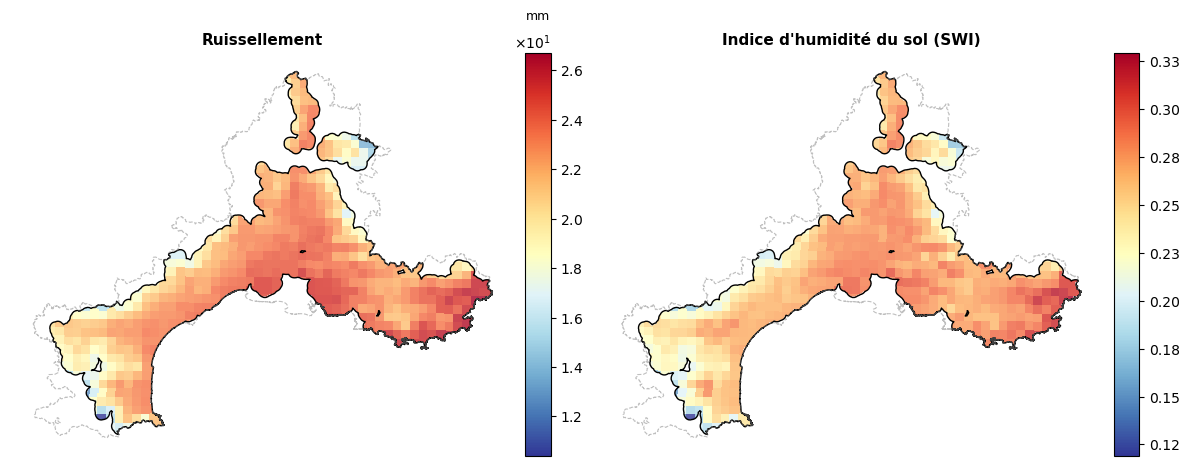

In [25]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable
import math

# --- 1. MISE À JOUR DES COVARIABLES ---
COVARIABLES = ["runc_q", "swi_q"]

# Associer chaque covariable à sa colonne dans siclima_values
grid_siclima = grid_proj.copy()
for i, cov_name in enumerate(COVARIABLES):
    grid_siclima[cov_name] = siclima_values[:, i]

# Correction des valeurs de SWI si elles sont restées sur une échelle 0-100
if "swi_q" in grid_siclima.columns and grid_siclima["swi_q"].max() > 1:
    grid_siclima["swi_q"] = grid_siclima["swi_q"] / 100.0

# Projections
study_zone_proj = study_zone.to_crs("EPSG:2154")
study_zone_bg_proj = study_zone_bg.to_crs("EPSG:2154")

# Configuration de la grille
n_cov = len(COVARIABLES)
n_cols = min(4, n_cov)
n_rows = math.ceil(n_cov / n_cols)

# Fermer les anciennes figures résiduelles pour éviter le message "0 Axes"
plt.close('all')

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))

if n_cov == 1:
    axes_flat = [axes]
else:
    axes_flat = axes.flatten()

# --- 2. DICTIONNAIRE DES TITRES ---
labels_cov = {
    "runc_q": "Ruissellement",
    "swi_q": "Indice d'humidité du sol (SWI)"
}

# --- Boucle de tracé ---
for i, cov_name in enumerate(COVARIABLES):
    ax = axes_flat[i]
    
    # 1. On sépare proprement l'espace pour y glisser la colorbar à côté de la carte
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1) # Crée un axe dédié à droite
    
    # 2. On dessine la carte (cmap="RdYlBu_r" : rouge=faible, jaune=moyen, bleu=fort)
    grid_siclima.dropna(subset=[cov_name]).plot(
        ax=ax, 
        column=cov_name, 
        cmap="RdYlBu_r", 
        legend=True, 
        cax=cax,  
        alpha=0.8
    )
    
    # --- 3. CONFIGURATION DES FORMATS ET LABELS DE COLORBAR ---
    if cov_name == "runc_q":
        formatter = ScalarFormatter(useMathText=True)
        formatter.set_powerlimits((0, 0))  # Force la notation scientifique pour le ruissellement
        cax.yaxis.set_major_formatter(formatter)
        cax.set_title("mm", fontsize=9, pad=10)
        
    elif cov_name == "swi_q":
        # Pas de notation scientifique pour le SWI afin de garder l'affichage de 0 à 1 (ex: 0.2, 0.4...)
        cax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:.2f}".format(x)))
    
    # 4. Tracé des contours de la zone d'étude
    study_zone_proj.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)
    study_zone_bg_proj.plot(ax=ax, facecolor="none", edgecolor="grey",
                            linewidth=0.8, linestyle="--", alpha=0.5)
    
    # 5. Titre et nettoyage de l'axe de la carte
    titre = labels_cov.get(cov_name, cov_name)
    ax.set_title(titre, fontsize=11, fontweight="bold")
    ax.set_axis_off()

# Masquer les axes vides restants
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis("off")

plt.tight_layout()
plt.show()

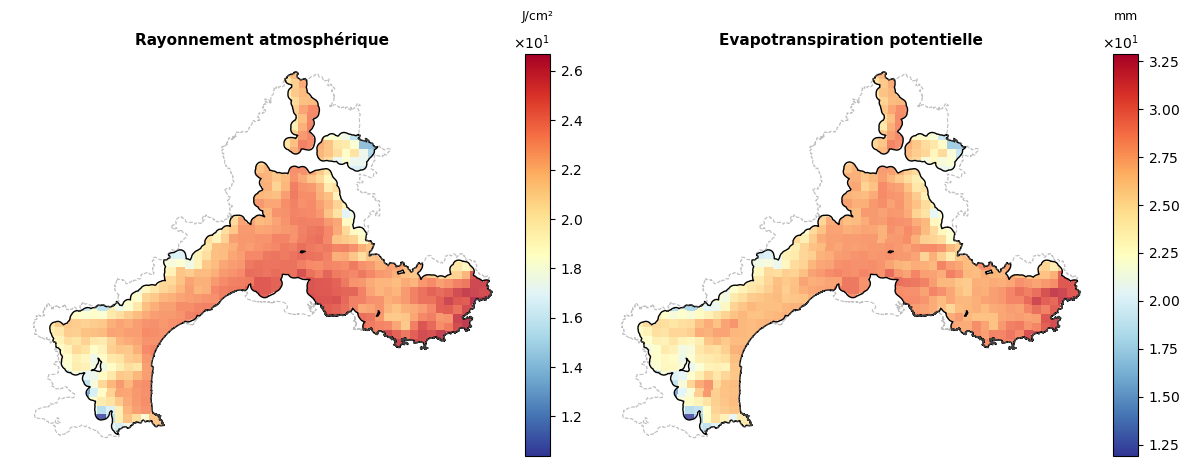

In [26]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable
import math

COVARIABLES = ["dli_q","etp_q"]  # Ajoutez vos autres variables ici

# Associer chaque covariable à sa colonne dans siclima_values
grid_siclima = grid_proj.copy()
for i, cov_name in enumerate(COVARIABLES):
    grid_siclima[cov_name] = siclima_values[:, i]

# Projections
study_zone_proj = study_zone.to_crs("EPSG:2154")
study_zone_bg_proj = study_zone_bg.to_crs("EPSG:2154")

# Configuration de la grille
n_cov = len(COVARIABLES)
n_cols = min(4, n_cov)
n_rows = math.ceil(n_cov / n_cols)

# Fermer les anciennes figures résiduelles pour éviter le message "0 Axes"
plt.close('all')

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))

if n_cov == 1:
    axes_flat = [axes]
else:
    axes_flat = axes.flatten()

labels_cov = {
    "dli_q": "Rayonnement atmosphérique","etp_q": "Evapotranspiration potentielle"
}

# --- Boucle de tracé ---
for i, cov_name in enumerate(COVARIABLES):
    ax = axes_flat[i]
    
    # 1. On sépare proprement l'espace pour y glisser la colorbar à côté de la carte
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1) # Crée un axe dédié à droite
    
    # 2. On dessine la carte en lui disant exactement où placer la colorbar (cax=cax)
    grid_siclima.dropna(subset=[cov_name]).plot(
        ax=ax, 
        column=cov_name, 
        cmap="RdYlBu_r",
        legend=True, 
        cax=cax,  # Force l'utilisation de l'axe de colorbar créé ci-dessus
        alpha=0.8
    )
    
    # 3. On applique la notation scientifique sur cette colorbar
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((0, 0))  # Force la notation scientifique
    cax.yaxis.set_major_formatter(formatter)
    
    # Optionnel : Ajout du label d'unité au-dessus de la colorbar
    if cov_name == "dli_q":
        cax.set_title("J/cm²", fontsize=9, pad=10)
    elif cov_name == "etp_q":
        cax.set_title("mm", fontsize=9, pad=10)
    
    # 4. Tracé des contours de la zone d'étude
    study_zone_proj.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)
    study_zone_bg_proj.plot(ax=ax, facecolor="none", edgecolor="grey",
                            linewidth=0.8, linestyle="--", alpha=0.5)
    
    # 5. Titre et nettoyage de l'axe de la carte
    titre = labels_cov.get(cov_name, cov_name)
    ax.set_title(titre, fontsize=11, fontweight="bold")
    ax.set_axis_off()

# Masquer les axes vides restants
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis("off")

plt.tight_layout()
plt.show()

## 8. SPLIT FOR TEST/TRAINING

In [27]:
from sklearn.model_selection import KFold

# --- 1. Sélection des cellules observées (inchangé) ---
obs_indices = np.where(observed_mask.numpy())[0]
X_obs = X_tensor[observed_mask]
y_obs = y_tensor[observed_mask]
print(f"📍 Cellules observées : {len(obs_indices)}")

coords_obs  = coords_full[obs_indices]
igapex_obs = igapex_full[obs_indices]

# --- 2. Validation Croisée aléatoire (K-Fold non-spatial) ---
N_SPLITS = 10  # même nombre de folds que ta version LOBO, à ajuster si besoin
SEED = 42

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

# --- 3. Construction des datasets par fold ---
x_trains, y_trains = [], []
x_vals,   y_vals   = [], []

for ind_train, ind_val in kf.split(X_obs):
    x_trains.append(X_obs[ind_train])
    y_trains.append(y_obs[ind_train])
    x_vals.append(X_obs[ind_val])
    y_vals.append(y_obs[ind_val])

# --- 4. Affichage des Folds ---
print(f"✅ {N_SPLITS} folds créés via Scikit-Learn (Mode K-Fold aléatoire) :")
for i in range(N_SPLITS):
    n_train = len(x_trains[i])
    n_val   = len(x_vals[i])
    n_pos_t = y_trains[i].sum().item()
    n_pos_v = y_vals[i].sum().item()
    print(f"   Fold {i+1:02d} — Train : {n_train:03d} ({n_pos_t:.0f} présences) "
          f"| Val : {n_val:02d} ({n_pos_v:.0f} présences)")

📍 Cellules observées : 229
✅ 10 folds créés via Scikit-Learn (Mode K-Fold aléatoire) :
   Fold 01 — Train : 206 (694 présences) | Val : 23 (47 présences)
   Fold 02 — Train : 206 (701 présences) | Val : 23 (40 présences)
   Fold 03 — Train : 206 (688 présences) | Val : 23 (53 présences)
   Fold 04 — Train : 206 (696 présences) | Val : 23 (45 présences)
   Fold 05 — Train : 206 (617 présences) | Val : 23 (124 présences)
   Fold 06 — Train : 206 (649 présences) | Val : 23 (92 présences)
   Fold 07 — Train : 206 (635 présences) | Val : 23 (106 présences)
   Fold 08 — Train : 206 (598 présences) | Val : 23 (143 présences)
   Fold 09 — Train : 206 (696 présences) | Val : 23 (45 présences)
   Fold 10 — Train : 207 (695 présences) | Val : 22 (46 présences)


In [28]:
# # --- 1. Extraction des coordonnées ---
# obs_indices = np.where(observed_mask.numpy())[0]
# grid_wgs84  = grid.to_crs("EPSG:4326")
# coords_obs  = np.array([
#     (grid_wgs84.geometry.iloc[i].centroid.x,
#      grid_wgs84.geometry.iloc[i].centroid.y)
#     for i in obs_indices
# ])

# # Tenseurs sur cellules observées uniquement
# X_obs = X_tensor[observed_mask]
# y_obs = y_tensor[observed_mask]

# print(f"📍 Cellules observées : {len(obs_indices)}")


# # --- 2. Création de la grille spatiale manuelle (5x5) ---
# lon = coords_obs[:, 0]
# lat = coords_obs[:, 1]

# # On découpe l'amplitude des lons/lats en 4 intervalles
# # lon_bins = np.linspace(lon.min(), lon.max(), 5)
# # lat_bins = np.linspace(lat.min(), lat.max(), 5)

# lon_bins = np.percentile(lon, [0, 100/4, 200/4, 100])
# lat_bins = np.percentile(lat, [0, 100/4, 200/4, 100])

# # On attribue à chaque point son index de case (de 0 à 4)
# lon_id = np.digitize(lon, lon_bins[:-1]) - 1
# lat_id = np.digitize(lat, lat_bins[:-1]) - 1

# # On combine les ID (ex: lon_id=2 et lat_id=3 devient le groupe unique "2_3")
# # On utilise np.unique(..., return_inverse=True) pour transformer ça en entiers propres (0, 1, 2...)
# spatial_groups_str = [f"{lon}_{lat}" for lon, lat in zip(lon_id, lat_id)]
# _, spatial_groups = np.unique(spatial_groups_str, return_inverse=True)


# # --- 3. Validation Croisée avec LeaveOneGroupOut ---
# logo = LeaveOneGroupOut()
# # Le nombre de splits est égal au nombre de groupes spatiaux uniques occupés
# N_SPLITS = logo.get_n_splits(groups=spatial_groups)


# # --- 4. Construction des datasets par fold ---
# x_trains, y_trains = [], []
# x_vals,   y_vals   = [], []

# # .split() prend nos groupes spatiaux en argument
# for ind_train, ind_val in logo.split(X_obs, y_obs, groups=spatial_groups):
#     x_trains.append(X_obs[ind_train])
#     y_trains.append(y_obs[ind_train])
#     x_vals.append(X_obs[ind_val])
#     y_vals.append(y_obs[ind_val])


# # --- 5. Affichage des Folds (LOO Spatial avec scikit-learn) ---
# print(f"✅ {N_SPLITS} folds créés via Scikit-Learn (Mode Leave-One-Block-Out) :")
# for i in range(N_SPLITS):
#     n_train = len(x_trains[i])
#     n_val   = len(x_vals[i])
#     n_pos_t = y_trains[i].sum().item()
#     n_pos_v = y_vals[i].sum().item()
#     print(f"   Fold {i+1:02d} — Train : {n_train:03d} ({n_pos_t:.0f} présences) "
#           f"| Val : {n_val:02d} ({n_pos_v:.0f} présences)")

In [29]:
# # 1. Configuration de la figure avec 2 sous-graphiques côte à côte (1 ligne, 2 colonnes)
# fig, axes = plt.subplots(1, 2, figsize=(18, 8))
# study_zone_wgs = study_zone.to_crs("EPSG:4326")

# # 2. On récupère le générateur de splits de scikit-learn
# logo_viz = LeaveOneGroupOut().split(X_obs, y_obs, groups=spatial_groups)

# # On va boucler sur les folds et dessiner uniquement les deux premiers
# for fold_idx, (ind_train, ind_val) in enumerate(logo_viz):
#     if fold_idx > 1:  # On s'arrête après le fold index 1 (donc le 2ème fold)
#         break
        
#     ax = axes[fold_idx]  # Sélection de l'axe (0 pour le Fold 1, 1 pour le Fold 2)
    
#     # Extraction des coordonnées pour ce fold spécifique
#     train_coords = coords_obs[ind_train]
#     val_coords   = coords_obs[ind_val]
    
#     # Dessin du contour de la zone d'étude
#     study_zone_wgs.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.5, alpha=0.5)
#     study_zone_bg_wgs.plot(ax=ax, facecolor="none", edgecolor="grey", linewidth=1.2, linestyle="--", alpha=0.6)

#     # Affichage des points d'entraînement (Bleu)
#     ax.scatter(train_coords[:, 0], train_coords[:, 1],
#                c='#3498db', s=25, alpha=0.7, 
#                label=f'Train (n={len(train_coords)})',
#                edgecolor='white', linewidth=0.3)
    
#     # Affichage des points de validation (Rouge)
#     ax.scatter(val_coords[:, 0], val_coords[:, 1],
#                c='#e74c3c', s=35, alpha=0.9, 
#                label=f'Val (n={len(val_coords)})',
#                edgecolor='black', linewidth=0.5)  # Légèrement accentué pour les petits blocs
    
#     # Personnalisation de l'axe courant
#     ax.set_title(f'Leave-One-Block-Out — Fold {fold_idx + 1} / {N_SPLITS}',
#                  fontsize=13, fontweight='bold')
#     ax.set_xlabel('Longitude')
#     ax.set_ylabel('Latitude')
#     ax.legend(fontsize=10, loc='upper left')
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
    
# # Ajustement global et affichage
# plt.tight_layout()
# plt.show()

## 9. MODEL TRAINING

In [30]:
# --- 1. Configuration des Hyperparamètres ---
class Args:
    def __init__(self):
        self.learning_rate = 0.03
        self.epoch         = 100
        self.hidden_nbr    = 2
        self.weight_decay  = 5e-2
        self.batch_size    = 32

args        = Args()
hidden_size = 256 # best_params["hidden_size"]
dropout_p   = 0.4 #best_params["dropout_p"]

# --- 2. Allocation du Device (CPU/GPU) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device : {device}")

# --- 3. Paramètres structurels du Réseau de Neurones ---
# Dynamique : s'adapte automatiquement au nombre de covariables présentes dans X_obs
input_size  = X_obs.shape[1]  

print(f"📐 Architecture — Entrée : {input_size} neurones (features)")
print(f"🔄 Nombre de Folds à entraîner au total : {N_SPLITS}")

# Nombre de colonnes continues (tout sauf les one-hot RU)
n_onehot     = len(ru_classes)  # 6
n_continuous = X_obs.shape[1] - n_onehot

🖥️  Device : cuda
📐 Architecture — Entrée : 13 neurones (features)
🔄 Nombre de Folds à entraîner au total : 10


In [31]:
def train_model(X_train, y_train, X_val, y_val, args, hidden_size=128, device="cpu"):
    
    model     = mlp_model(X_train.shape[1], hidden_size, args.hidden_nbr, dropout_p).to(device)
    criterion = deepmaxent_loss()
    #criterion = ce_loss()

    optimizer = optim.AdamW(model.parameters(),
                            lr=args.learning_rate,
                            weight_decay=args.weight_decay)

    X_train_dev = X_train.to(device)
    y_train_dev = y_train.to(device)
    X_val_dev   = X_val.to(device)
    y_val_dev   = y_val.to(device)

    train_losses, val_losses = [], []
    best_val_loss    = float('inf')
    best_model_state = None

    print("🚀 Entraînement...")
    print("=" * 60)

    for epoch in tqdm(range(args.epoch), desc="Training"):

        # --- Phase train : TOUTES les cellules d'un coup ---
        model.train()
        optimizer.zero_grad()
        outputs    = model(X_train_dev)           # (n_train, 2)
        loss       = criterion(outputs, y_train_dev)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        # --- Phase validation ---
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_dev)        # (n_val, 2)
            val_loss    = criterion(val_outputs, y_val_dev).item()
        val_losses.append(val_loss)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"   Epoch {epoch+1:3d} | Train: {loss.item():.4f} | Val: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_model_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_state)

    # AUC sur le meilleur modèle
    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_dev)             # (n_val, 2)
        val_probs  = torch.softmax(val_logits, dim=0)[:, 0].cpu().numpy()

    y_val_np     = (y_val[:, 0] / (y_val[:, 0] + y_val[:, 1]).clamp(min=1e-8)).numpy()
    y_val_binary = (y_val_np >= 0.5).astype(int)

    if len(np.unique(y_val_binary)) < 2:
        print("⚠️ Val set contient une seule classe — AUC indéfinie.")
        return None

    val_auc = roc_auc_score(y_val_binary, val_probs)

    print("=" * 60)
    print(f"✅ Meilleur Val Loss : {best_val_loss:.4f} | AUC : {val_auc:.4f}")

    return {
        "model"        : model,
        "train_losses" : train_losses,
        "val_losses"   : val_losses,
        "best_val_loss": best_val_loss,
        "val_auc"      : val_auc
    }

### ENTRAINEMENT

In [32]:
all_results = []

for fold_idx in range(N_SPLITS):
    print(f"\n{'='*60}")
    print(f"🔁 FOLD {fold_idx + 1} / {N_SPLITS} (Leave-One-Block-Out)")
    print(f"{'='*60}")

    # Preprocessing du fold
    X_train_raw = x_trains[fold_idx]
    X_val_raw   = x_vals[fold_idx]
    y_train_f   = y_trains[fold_idx]
    y_val_f     = y_vals[fold_idx]

    # Suppression NaN
    train_nan_mask = torch.isnan(X_train_raw).any(dim=1)
    val_nan_mask   = torch.isnan(X_val_raw).any(dim=1)
    
    X_train_clean  = X_train_raw[~train_nan_mask]
    y_train_clean  = y_train_f[~train_nan_mask]
    X_val_clean    = X_val_raw[~val_nan_mask]
    y_val_clean    = y_val_f[~val_nan_mask]

    # ⚠️ SÉCURITÉ CRITIQUE : Vérifier si le jeu de validation ou d'entraînement est vide après nettoyage
    if len(X_val_clean) == 0:
        print(f"⏩ Fold {fold_idx + 1} ignoré : Aucune donnée de validation valide après suppression des NaNs.")
        continue
    if len(X_train_clean) == 0:
        print(f"⏩ Fold {fold_idx + 1} ignoré : Aucune donnée d'entraînement valide après suppression des NaNs.")
        continue

    # Normalisation (fit sur train uniquement)
    scaler_fold = StandardScaler()
    X_train_cont_scaled = scaler_fold.fit_transform(X_train_clean[:, :n_continuous].numpy())
    X_val_cont_scaled   = scaler_fold.transform(X_val_clean[:, :n_continuous].numpy())

    X_train_tensor_f = torch.tensor(
        np.concatenate([X_train_cont_scaled, X_train_clean[:, n_continuous:].numpy()], axis=1),
        dtype=torch.float32
    )
    X_val_tensor_f = torch.tensor(
        np.concatenate([X_val_cont_scaled, X_val_clean[:, n_continuous:].numpy()], axis=1),
        dtype=torch.float32
    )

    # Entraînement
    fold_results = train_model(
        X_train     = X_train_tensor_f,
        y_train     = y_train_clean,
        X_val       = X_val_tensor_f,
        y_val       = y_val_clean,
        args        = args,
        hidden_size = hidden_size,
        device      = device
    )

    if fold_results is not None:
        all_results.append({
            "fold"        : fold_idx + 1,
            "results"     : fold_results,
            "scaler"      : scaler_fold,
            "val_loss"    : fold_results["best_val_loss"],
            "val_auc"  : fold_results["val_auc"]
        })

# --- Résumé de la Cross-Validation Spatiale ---
print(f"\n📊 RÉSUMÉ CROSS-VALIDATION SPATIALE")
print("=" * 60)
if len(all_results) > 0:
    val_losses = [r["val_loss"] for r in all_results]
    val_aucs   = [r["val_auc"]  for r in all_results]
    print(f"   Nombre de folds validés : {len(all_results)} / {N_SPLITS}")
    print(f"   AUC par fold : {[f'{v:.4f}' for v in val_aucs]}")
    print(f"   AUC moyenne  : {np.mean(val_aucs):.4f} ± {np.std(val_aucs):.4f}")
    
    print(f"   DeepMaxEnt par fold : {[f'{v:.4f}' for v in val_losses]}")
    print(f"   DeepMaxEnt moyenne  : {np.mean(val_losses):.4f} ± {np.std(val_losses):.4f}")
    
    # Identification du meilleur fold (utile si vous appliquez une stratégie d'Ensemble ou d'Early Stopping)
    best_fold_idx = np.argmax(val_aucs)
    best_fold = all_results[best_fold_idx]
    print(f"   Meilleur fold : Fold {best_fold['fold']} (AUC = {best_fold['val_auc']:.4f})")
else:
    print("❌ Aucun fold n'a pu être entraîné avec succès.")


🔁 FOLD 1 / 10 (Leave-One-Block-Out)


🚀 Entraînement...


Training:   0%|                                                                                | 0/100 [00:00<?, ?it/s]

Training:   1%|▋                                                                       | 1/100 [00:00<00:16,  5.94it/s]

   Epoch   1 | Train: 0.0267 | Val: 0.1829
   Epoch  10 | Train: 0.0248 | Val: 0.1353
   Epoch  20 | Train: 0.0237 | Val: 0.1358


...

Training:  57%|███████████████████████████████████████▉                              | 57/100 [00:00<00:00, 569.05it/s]

   Epoch  40 | Train: 0.0226 | Val: 0.1281
   Epoch  50 | Train: 0.0223 | Val: 0.1208
   Epoch  60 | Train: 0.0224 | Val: 0.1285
   Epoch  70 | Train: 0.0225 | Val: 0.1233


   Epoch  80 | Train: 0.0219 | Val: 0.1334
   Epoch  90 | Train: 0.0220 | Val: 0.1295
   Epoch 100 | Train: 0.0218 | Val: 0.1294


Training: 100%|█████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 588.44it/s]

✅ Meilleur Val Loss : 0.1196 | AUC : 0.7083

📊 RÉSUMÉ CROSS-VALIDATION SPATIALE
   Nombre de folds validés : 10 / 10
   AUC par fold : ['0.5152', '0.6429', '0.4020', '0.8333', '0.6964', '0.7698', '0.6250', '0.7321', '0.5625', '0.7083']
   AUC moyenne  : 0.6488 ± 0.1218
   DeepMaxEnt par fold : ['0.1337', '0.1418', '0.1208', '0.1138', '0.1266', '0.1253', '0.1218', '0.1237', '0.1308', '0.1196']
   DeepMaxEnt moyenne  : 0.1258 ± 0.0076
   Meilleur fold : Fold 4 (AUC = 0.8333)


In [33]:
# Extraction du modèle du meilleur fold
if len(all_results) > 0:
    best_fold_idx = np.argmax([r["val_auc"] for r in all_results])   # <-- changé
    best_model_entry = all_results[best_fold_idx]

    model = best_model_entry["results"]["model"]
    scaler_grid = best_model_entry["scaler"]

    print(f"✅ Modèle chargé depuis le Fold {best_model_entry['fold']} !")
else:
    print("❌ Impossible de charger un modèle, aucun entraînement réussi.")

✅ Modèle chargé depuis le Fold 4 !


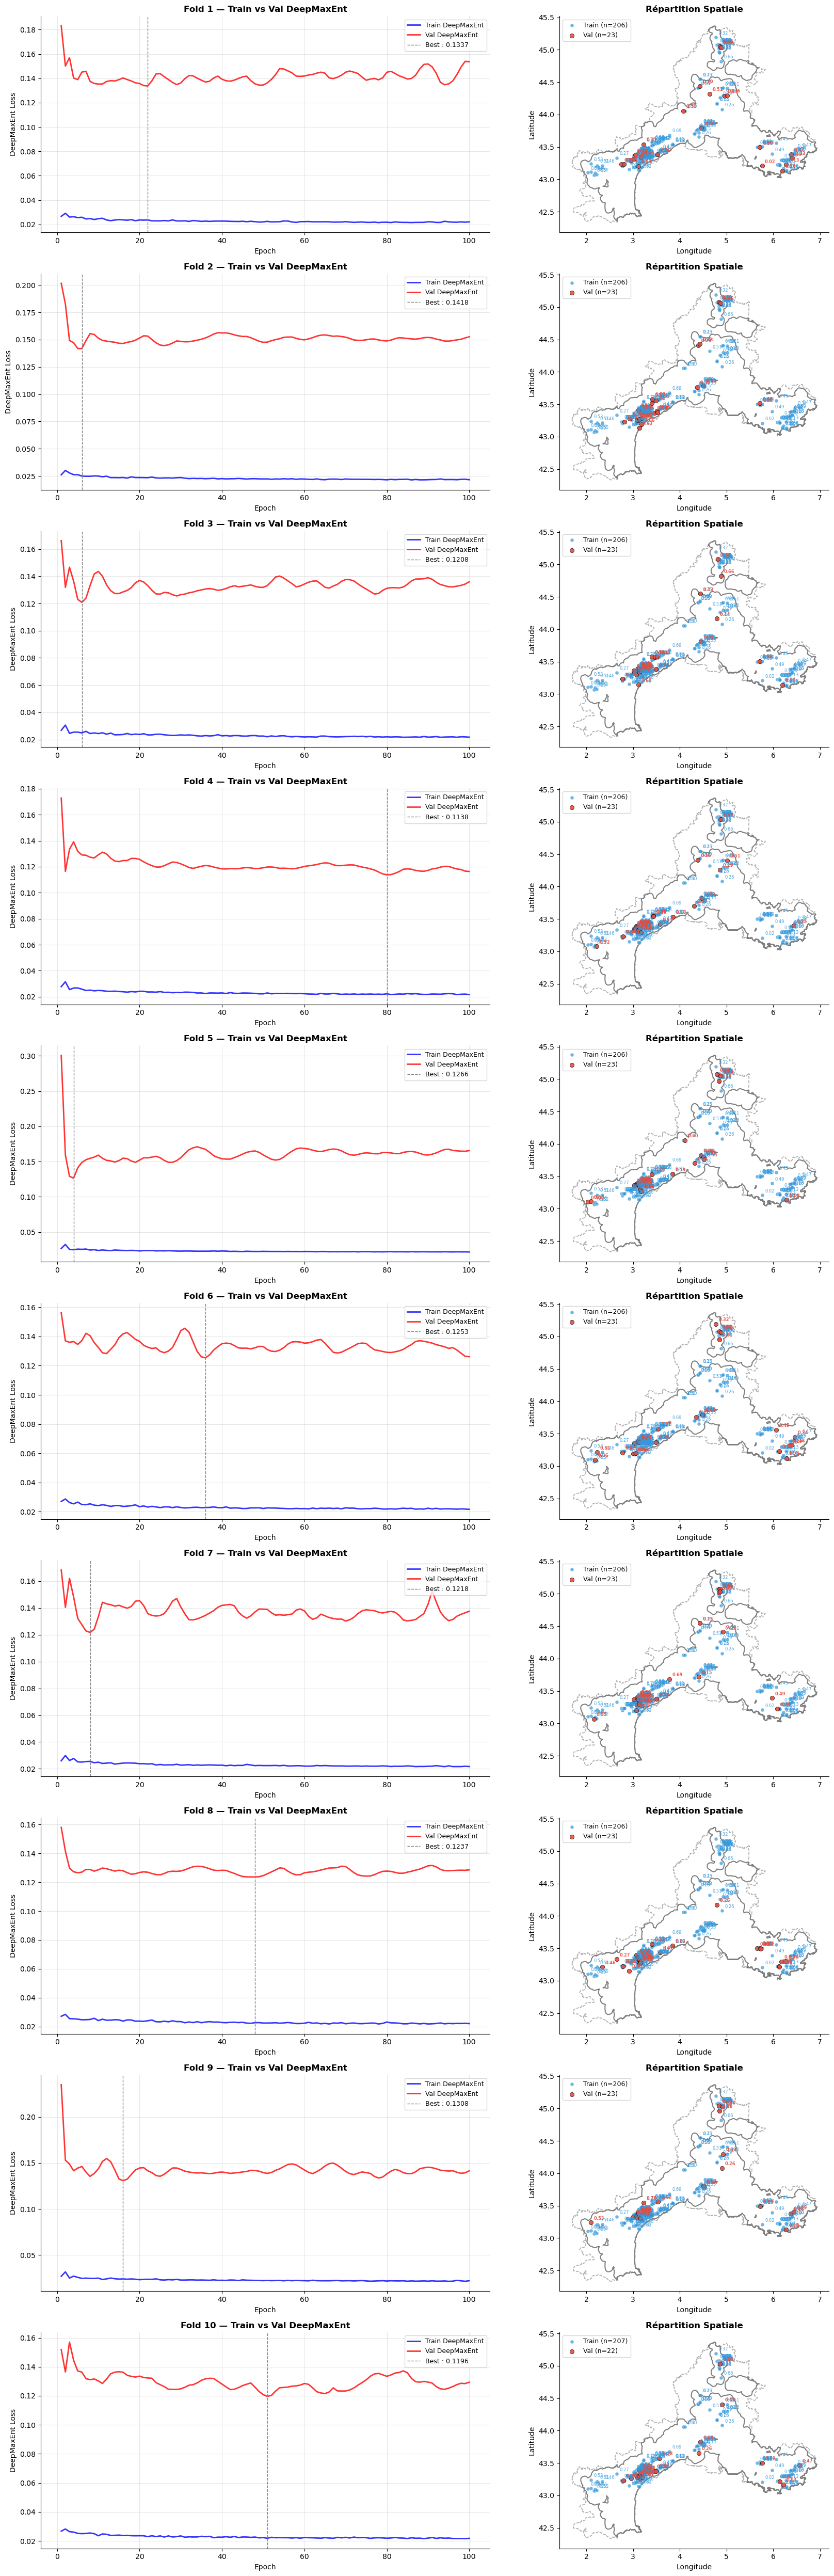


📊 MÉTRIQUES FINALES PAR FOLD (DEEPMAXENT)
   Fold 01 — Meilleure Val DeepMaxEnt : 0.1337 | AUC : 0.5152
   Fold 02 — Meilleure Val DeepMaxEnt : 0.1418 | AUC : 0.6429
   Fold 03 — Meilleure Val DeepMaxEnt : 0.1208 | AUC : 0.4020
   Fold 04 — Meilleure Val DeepMaxEnt : 0.1138 | AUC : 0.8333
   Fold 05 — Meilleure Val DeepMaxEnt : 0.1266 | AUC : 0.6964
   Fold 06 — Meilleure Val DeepMaxEnt : 0.1253 | AUC : 0.7698
   Fold 07 — Meilleure Val DeepMaxEnt : 0.1218 | AUC : 0.6250
   Fold 08 — Meilleure Val DeepMaxEnt : 0.1237 | AUC : 0.7321
   Fold 09 — Meilleure Val DeepMaxEnt : 0.1308 | AUC : 0.5625
   Fold 10 — Meilleure Val DeepMaxEnt : 0.1196 | AUC : 0.7083


In [34]:
# 1. On récupère le nombre réel de folds entraînés avec succès
n_effective_folds = len(all_results)

# 2. On crée une grille : n_effective_folds lignes, 2 colonnes (Loss à gauche, Carte à droite)
fig, axes = plt.subplots(n_effective_folds, 2, figsize=(18, 5 * n_effective_folds))

# Sécurité si all_results ne contient qu'un seul fold (pour que axes reste une matrice 2D)
if n_effective_folds == 1:
    axes = np.expand_dims(axes, axis=0)

# 3. Préparation des données cartographiques
study_zone_wgs = study_zone.to_crs("EPSG:4326")

# On recrée le générateur de split pour synchroniser les cartes avec les boucles de résultats
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
logo_viz = list(kf.split(X_obs))

# 4. Boucle unique sur les folds
for fold_idx, fold_data in enumerate(all_results):
    results_f = fold_data["results"]
    epochs    = range(1, len(results_f['train_losses']) + 1)
    
    # Récupération des indices géographiques correspondants au fold courant
    ind_train, ind_val = logo_viz[fold_idx]
    train_coords = coords_obs[ind_train]
    val_coords   = coords_obs[ind_val]

    # -----------------------------------------
    # 📈 COLONNE 1 (Axe gauche) : Courbe de Loss
    # -----------------------------------------
    ax_loss = axes[fold_idx, 0]
    ax_loss.plot(epochs, results_f['train_losses'], 'b-', linewidth=2, label='Train DeepMaxEnt', alpha=0.8)
    ax_loss.plot(epochs, results_f['val_losses'],   'r-', linewidth=2, label='Val DeepMaxEnt',   alpha=0.8)
    ax_loss.axvline(x=results_f['val_losses'].index(results_f['best_val_loss']) + 1,
                    color='gray', linestyle='--', linewidth=1,
                    label=f"Best : {results_f['best_val_loss']:.4f}")
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('DeepMaxEnt Loss')
    ax_loss.set_title(f'Fold {fold_data["fold"]} — Train vs Val DeepMaxEnt', fontweight='bold')
    ax_loss.legend(fontsize=9, loc='upper right')
    ax_loss.grid(True, alpha=0.3)
    ax_loss.spines['top'].set_visible(False)
    ax_loss.spines['right'].set_visible(False)

    # -----------------------------------------
    # 🌍 COLONNE 2 (Axe droit) : Carte des observations
    # -----------------------------------------
    ax_map = axes[fold_idx, 1]
    
    # Dessin du contour de la zone d'étude
    study_zone_wgs.plot(ax=ax_map, facecolor='none', edgecolor='black', linewidth=1.5, alpha=0.5)
    study_zone_bg_wgs.plot(ax=ax_map, facecolor="none", edgecolor="grey", linewidth=1.2, linestyle="--", alpha=0.6)

    # Affichage des points d'entraînement (Bleu)
    ax_map.scatter(train_coords[:, 0], train_coords[:, 1],
                   c='#3498db', s=25, alpha=0.7, 
                   label=f'Train (n={len(train_coords)})',
                   edgecolor='white', linewidth=0.3)
    
    # Affichage des points de validation (Rouge)
    ax_map.scatter(val_coords[:, 0], val_coords[:, 1],
                   c='#e74c3c', s=35, alpha=0.9, 
                   label=f'Val (n={len(val_coords)})',
                   edgecolor='black', linewidth=0.5)

    # -----------------------------------------
    # 🔢 Annotation des valeurs iG-APEX à côté des points
    # -----------------------------------------
    igapex_train = igapex_obs[ind_train]
    igapex_val   = igapex_obs[ind_val]

    for (x, y), val in zip(train_coords, igapex_train):
        ax_map.annotate(f"{val:.2f}", (x, y),
                         textcoords="offset points", xytext=(4, 4),
                         fontsize=6, color='#3498db', alpha=0.9)

    for (x, y), val in zip(val_coords, igapex_val):
        ax_map.annotate(f"{val:.2f}", (x, y),
                         textcoords="offset points", xytext=(4, 4),
                         fontsize=6, color='#e74c3c', alpha=0.9, fontweight='bold')
    
    # Personnalisation de l'axe de la carte
    ax_map.set_title(f'Répartition Spatiale', fontsize=12, fontweight='bold')
    ax_map.set_xlabel('Longitude')
    ax_map.set_ylabel('Latitude')
    ax_map.legend(fontsize=9, loc='upper left')
    ax_map.spines['top'].set_visible(False)
    ax_map.spines['right'].set_visible(False)

# Ajustement global et affichage de la grille finale
plt.tight_layout()
plt.show()

# --- Affichage des métriques finales épurées en console ---
print("\n📊 MÉTRIQUES FINALES PAR FOLD (DEEPMAXENT)")
print("=" * 50)
for fold_data in all_results:
    r = fold_data["results"]
    print(f"   Fold {fold_data['fold']:02d} — Meilleure Val DeepMaxEnt : {r['best_val_loss']:.4f} | AUC : {r['val_auc']:.4f}")

In [35]:
print("📊 ÉVALUATION GLOBALE (CUMULÉE) PAR FOLD")
print("=" * 60)

from scipy.stats import kendalltau

all_val_preds = []
all_val_trues = []

for fold_data in all_results:
    model_f  = fold_data["results"]["model"]
    fold_idx = fold_data["fold"] - 1
    X_val_raw    = x_vals[fold_idx]
    y_val_f      = y_vals[fold_idx]
    val_nan_mask = torch.isnan(X_val_raw).any(dim=1)
    X_val_clean  = X_val_raw[~val_nan_mask]
    y_val_clean  = y_val_f[~val_nan_mask]

    if len(X_val_clean) == 0:
        continue

    X_val_cont_scaled = fold_data["scaler"].transform(X_val_clean[:, :n_continuous].numpy())
    X_val_tensor_f    = torch.tensor(
        np.concatenate([X_val_cont_scaled, X_val_clean[:, n_continuous:].numpy()], axis=1),
        dtype=torch.float32
    )

    model_f.eval()
    with torch.no_grad():
        logits    = model_f(X_val_tensor_f.to(device))               # (n_val, 2)
        val_preds = logits[:, 0].cpu().numpy() # score présence

    # Ratio présence par cellule
    val_true = (y_val_clean[:, 0] / (y_val_clean[:, 0] + y_val_clean[:, 1])).numpy()

    all_val_preds.extend(val_preds)
    all_val_trues.extend(val_true)

    # Métrique locale
    tau, _ = kendalltau(val_true, val_preds)
    print(f"   Fold {fold_data['fold']:02d} ({len(val_true):02d} cellules) — Kendall τ : {tau:.4f}")

# --- MÉTRIQUES GLOBALES ---
print("\n" + "="*60)
print("📈 PERFORMANCE FINALE DU SYSTÈME SPATIAL (LOO)")
print("="*60)
y_pred_all    = np.array(all_val_preds)
y_true_all    = np.array(all_val_trues)
y_true_binary = (y_true_all >= 0.5).astype(int)   # majorité présences → 1
y_pred_class  = (y_pred_all >= 0.5).astype(int)

unique, counts = np.unique(y_true_binary, return_counts=True)
print(f"Labels dans y_true_binary : {dict(zip(unique, counts))}")

if len(np.unique(y_true_binary)) > 1:
    global_auc = roc_auc_score(y_true_binary, y_pred_all)
else:
    global_auc = float('nan')
    print("⚠️ AUC indéfinie : y_true ne contient qu'une seule classe")

global_acc     = accuracy_score(y_true_binary, y_pred_class)
global_tau, _  = kendalltau(y_true_all, y_pred_all)

print(f"   Nombre total de cellules validées  : {len(y_true_all)}")
print(f"   AUC-ROC Globale                    : {global_auc:.4f}  (discrimination binaire)")
print(f"   Accuracy Globale                   : {global_acc:.4f}  (seuil 0.5)")
print(f"   Kendall τ Global                   : {global_tau:.4f}  (corrélation des rangs)")

📊 ÉVALUATION GLOBALE (CUMULÉE) PAR FOLD
   Fold 01 (23 cellules) — Kendall τ : -0.0152
   Fold 02 (22 cellules) — Kendall τ : 0.1603
   Fold 03 (23 cellules) — Kendall τ : -0.0463
   Fold 04 (23 cellules) — Kendall τ : 0.4556
   Fold 05 (23 cellules) — Kendall τ : 0.2126
   Fold 06 (23 cellules) — Kendall τ : 0.3440
   Fold 07 (23 cellules) — Kendall τ : 0.1836
   Fold 08 (23 cellules) — Kendall τ : 0.3240
   Fold 09 (23 cellules) — Kendall τ : 0.0948
   Fold 10 (22 cellules) — Kendall τ : 0.2291

📈 PERFORMANCE FINALE DU SYSTÈME SPATIAL (LOO)
Labels dans y_true_binary : {np.int64(0): np.int64(79), np.int64(1): np.int64(149)}
   Nombre total de cellules validées  : 228
   AUC-ROC Globale                    : 0.5486  (discrimination binaire)
   Accuracy Globale                   : 0.3904  (seuil 0.5)
   Kendall τ Global                   : 0.0552  (corrélation des rangs)


In [36]:
# ==============================================================================
# SCORE COMBINÉ OUT-OF-FOLD — même pipeline (MC-Dropout) que la grille finale
# ==============================================================================
oof_score_combined = []
oof_std_combined   = []
oof_ic_apex_true   = []
oof_fold_id        = []

for fold_data in all_results:
    fold_idx = fold_data["fold"] - 1
    X_val_raw = x_vals[fold_idx]
    y_val_f   = y_vals[fold_idx]
    val_nan_mask = torch.isnan(X_val_raw).any(dim=1)
    X_val_clean  = X_val_raw[~val_nan_mask]
    y_val_clean  = y_val_f[~val_nan_mask]

    if len(X_val_clean) == 0:
        continue

    X_val_cont_scaled = fold_data["scaler"].transform(X_val_clean[:, :n_continuous].numpy())
    X_val_tensor_f = torch.tensor(
        np.concatenate([X_val_cont_scaled, X_val_clean[:, n_continuous:].numpy()], axis=1),
        dtype=torch.float32
    )

    model_f = fold_data["results"]["model"]

    # Même fonction que pour la grille (predict_with_uncertainty, MC-Dropout)
    _, _, mean_presence_v, std_presence_v, mean_absence_v, std_absence_v = predict_with_uncertainty(
        model=model_f, X_tensor=X_val_tensor_f, device=device, n_samples=100
    )

    p1_v, p2_v = np.asarray(mean_presence_v), np.asarray(mean_absence_v)
    s1_v, s2_v = np.asarray(std_presence_v),  np.asarray(std_absence_v)

    score_v = p1_v * (1 - p2_v)
    std_v   = np.sqrt((1 - p2_v) ** 2 * s1_v ** 2 + p1_v ** 2 * s2_v ** 2)
    ic_apex_true_v = (y_val_clean[:, 0] / (y_val_clean[:, 0] + y_val_clean[:, 1])).numpy()

    oof_score_combined.append(score_v)
    oof_std_combined.append(std_v)
    oof_ic_apex_true.append(ic_apex_true_v)
    oof_fold_id.extend([fold_data["fold"]] * len(score_v))

oof_score_combined = np.concatenate(oof_score_combined)
oof_std_combined    = np.concatenate(oof_std_combined)
oof_ic_apex_true    = np.concatenate(oof_ic_apex_true)
oof_fold_id         = np.array(oof_fold_id)

print(f"✅ {len(oof_score_combined)} paires (score_combined, iC-apex) OOF sur {len(all_results)} folds")

✅ 228 paires (score_combined, iC-apex) OOF sur 10 folds


In [37]:
# 1. Récupération robuste du meilleur fold basé sur vos résultats effectifs
best_fold_id = best_fold["fold"]
# On cherche l'index correspondant dans votre liste de départ (au cas où des folds manquent)
best_fold_idx = best_fold_id - 1 

y_train_best = y_trains[best_fold_idx]
y_train_best_ratio = (y_train_best[:, 0] / (y_train_best[:, 0] + y_train_best[:, 1]))
X_train_best = x_trains[best_fold_idx]

print(f"📊 Corrélations covariables → ratio présence iC-APEX (train fold {best_fold_id}) :")
print("=" * 65)

# Nettoyage des noms de fichiers de vos rasters
var_names_clean = [
    f.replace('data/cov/rasters/', '')
     .replace('alt/', '').replace('cwb/', '').replace('ru/', '')
     .replace('.tif', '')
    for f in raster_files[:n_continuous]  # toutes les continues
]

# --- Partie 1 : Covariables continues ---
for i, name in enumerate(var_names_clean):
    x_col = X_train_best[:, i]
    y_col = y_train_best_ratio
    
    # ⚠️ SÉCURITÉ CRITIQUE : Le masque doit filtrer les NaNs de X ET s'assurer de l'alignement avec Y
    # On crée un masque combiné pour éliminer les lignes contenant un NaN dans l'une ou l'autre variable
    mask = ~torch.isnan(x_col) & ~torch.isnan(y_col)
    
    # Si le masque élimine tout ou s'il n'y a pas assez de données pour une corrélation
    if mask.sum() < 2:
        print(f"   {name:40s} r = NaN (Données insuffisantes)")
        continue
        
    corr = np.corrcoef(x_col[mask].numpy(), y_col[mask].numpy())[0, 1]
    print(f"   {name:40s} r = {corr:.3f}")

# --- Partie 2 : Corrélations RU (one-hot) ---
print(f"📊 Corrélations RU (one-hot) → ratio présence iC-APEX (train fold {best_fold_id}) :")
print("=" * 65)

for j, cls in enumerate(ru_classes):
    x_col = X_train_best[:, n_continuous + j]
    y_col = y_train_best_ratio
    
    # Même masque de sécurité combiné pour le One-Hot encoding
    mask = ~torch.isnan(x_col) & ~torch.isnan(y_col)
    
    if mask.sum() < 2:
        print(f"   RU classe {cls:<2} r = NaN")
        continue
        
    corr = np.corrcoef(x_col[mask].numpy(), y_col[mask].numpy())[0, 1]
    
    # Formattage propre des libellés (conforme à vos nouvelles classes du rouge au bleu)
    label = f"RU classe {cls}"
    if cls == 9:
        label += " (non-sol)"
    elif cls == 1:
        label += " (< 50mm)"
    elif cls == 2:
        label += " (50-100mm)"
    elif cls == 3:
        label += " (100-150mm)"
    elif cls == 4:
        label += " (150-200mm)"
    elif cls == 5:
        label += " (>= 200mm)"
        
    print(f"   {label:35s} r = {corr:.3f}")

# --- Partie 3 : Corrélations SICLIMA ---
print(f"📊 Corrélations SICLIMA → ratio présence iC-APEX (train fold {best_fold_id}) :")
print("=" * 65)

siclima_start = n_continuous - len(COVARIABLES)  # = 20 - 16 = 4

for j, cov_name in enumerate(COVARIABLES):
    x_col = X_train_best[:, siclima_start + j]
    y_col = y_train_best_ratio

    mask = ~torch.isnan(x_col) & ~torch.isnan(y_col)

    if mask.sum() < 2:
        print(f"   {cov_name:40s} r = NaN (Données insuffisantes)")
        continue

    corr = np.corrcoef(x_col[mask].numpy(), y_col[mask].numpy())[0, 1]
    print(f"   {cov_name:40s} r = {corr:.3f}")

📊 Corrélations covariables → ratio présence iC-APEX (train fold 4) :
   alt\altitude_study_zone                  r = -0.203
   ru\ru_raster                             r = -0.062
   pente\slope                              r = 0.019
   exp\exposure                             r = -0.280
   pluvio/PLUIE_CUM_1km_2025-07-20          r = -0.256
📊 Corrélations RU (one-hot) → ratio présence iC-APEX (train fold 4) :
   RU classe 1 (< 50mm)                r = -0.290
   RU classe 2 (50-100mm)              r = 0.249
   RU classe 3 (100-150mm)             r = -0.094
   RU classe 4 (150-200mm)             r = 0.022
   RU classe 5 (>= 200mm)              r = nan
   RU classe 9 (non-sol)               r = nan
📊 Corrélations SICLIMA → ratio présence iC-APEX (train fold 4) :
   dli_q                                    r = -0.335
   etp_q                                    r = -0.296


## 10. GENERATE IG-APEX MAP

In [38]:
# ==============================================================================
#  ÉTAPES COMPLÈTES : PRÉDICTION SUR TOUTE LA GRILLE VIA LE MEILLEUR FOLD
# ==============================================================================
# 1. Sélection automatique du meilleur Fold entraîné
best_fold_idx = np.argmax([r["val_auc"] for r in all_results])
best_fold = all_results[best_fold_idx]
model = best_fold["results"]["model"]
scaler_grid = best_fold["scaler"]
print(f"✅ Modèle et Scaler extraits avec succès depuis le Fold {best_fold['fold']}")

# 2. Masquage de sécurité pour les NaNs globaux
valid_grid_mask = ~torch.isnan(X_tensor).any(dim=1)
X_grid_clean = X_tensor[valid_grid_mask]

# 3. Normalisation rigoureuse (uniquement sur les variables continues)
X_grid_cont_scaled = scaler_grid.transform(X_grid_clean[:, :n_continuous].numpy())
X_grid_combined = np.concatenate([X_grid_cont_scaled, X_grid_clean[:, n_continuous:].numpy()], axis=1)
X_grid_final_tensor = torch.tensor(X_grid_combined, dtype=torch.float32)
print(f"📊 Nombre total de cellules dans la grille : {len(X_tensor):,}")
print(f"🎯 Cellules valides prêtes pour l'inférence : {len(X_grid_final_tensor):,}")

# 4. Inférence Spatiale avec Monte Carlo Dropout
print("🚀 Calcul des prédictions et de l'incertitude (MC-Dropout)...")
mean_pred, std_pred, mean_presence, std_presence, mean_absence, std_absence = predict_with_uncertainty(
    model=model,
    X_tensor=X_grid_final_tensor,
    device=device,
    n_samples=100
)

# 5. Reconstruction des tenseurs complets (NaN pour les cellules invalides)
pred_presence_full = torch.full((len(X_tensor),), float('nan'), dtype=torch.float32)
pred_absence_full  = torch.full((len(X_tensor),), float('nan'), dtype=torch.float32)
std_presence_full  = torch.full((len(X_tensor),), float('nan'), dtype=torch.float32)
std_absence_full   = torch.full((len(X_tensor),), float('nan'), dtype=torch.float32)

pred_presence_full[valid_grid_mask] = mean_presence
pred_absence_full[valid_grid_mask]  = mean_absence
std_presence_full[valid_grid_mask]  = std_presence
std_absence_full[valid_grid_mask]   = std_absence

print("🎉 Terminé !")
print(f"   pred_presence_full : {pred_presence_full.shape} — score DeepMaxEnt présences")
print(f"   pred_absence_full  : {pred_absence_full.shape}  — score DeepMaxEnt absences")
print(f"   std_presence_full  : {std_presence_full.shape}  — incertitude présences")
print(f"   std_absence_full   : {std_absence_full.shape}   — incertitude absences")

✅ Modèle et Scaler extraits avec succès depuis le Fold 4


📊 Nombre total de cellules dans la grille : 36,377
🎯 Cellules valides prêtes pour l'inférence : 33,799
🚀 Calcul des prédictions et de l'incertitude (MC-Dropout)...


🎉 Terminé !
   pred_presence_full : torch.Size([36377]) — score DeepMaxEnt présences
   pred_absence_full  : torch.Size([36377])  — score DeepMaxEnt absences
   std_presence_full  : torch.Size([36377])  — incertitude présences
   std_absence_full   : torch.Size([36377])   — incertitude absences


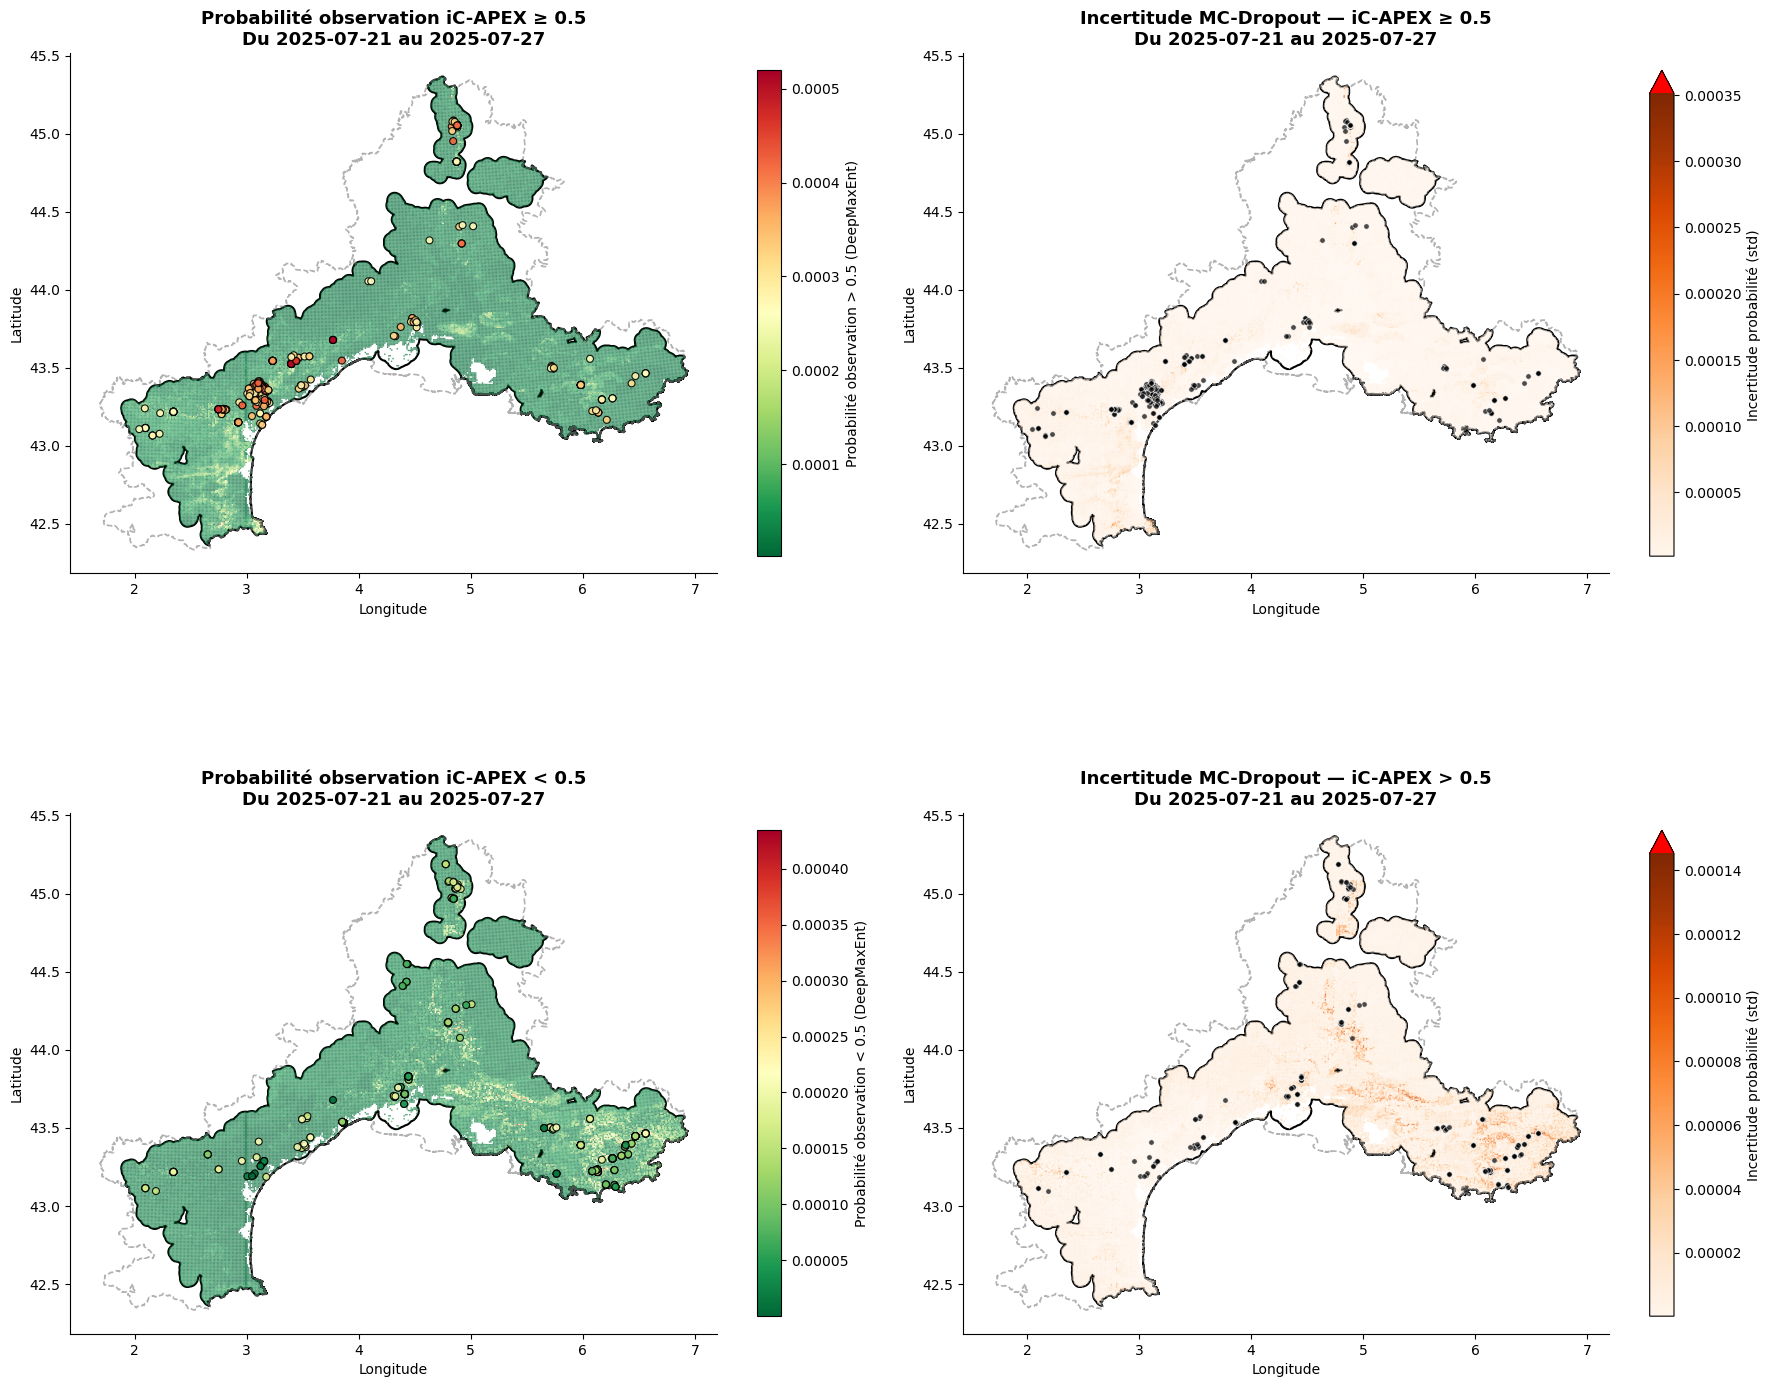

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Attribution des résultats à notre GeoDataFrame de la grille
grid_pred = grid_wgs.copy()
grid_pred['score_presence'] = pred_presence_full.numpy()
grid_pred['score_absence']  = pred_absence_full.numpy()
grid_pred['std_presence']   = std_presence_full.numpy()
grid_pred['std_absence']    = std_absence_full.numpy()

# Préparation de la variable terrain (on crée les objets géo une seule fois)
study_zone_wgs    = study_zone.to_crs("EPSG:4326")
study_zone_bg_wgs = study_zone_bg.to_crs("EPSG:4326")
df_zone_wgs       = df_zone.to_crs("EPSG:4326").copy()

# Séparation des points terrain par classe
df_presences = df_zone_wgs[df_zone_wgs['ic_apex'] >= 0.5]
df_absences  = df_zone_wgs[df_zone_wgs['ic_apex'] <  0.5]

# Colormap incertitude
cmap_incertitude = plt.colormaps['Oranges'].copy()
cmap_incertitude.set_over('red')

# --- Génération des 4 cartes (2 lignes x 2 colonnes) ---
fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# ==============================================================
# LIGNE 1 : Classe iC-APEX <= 0.5
# ==============================================================

# --- Carte 1 : Score <0.5 ---
ax1 = axes[0, 0]
study_zone_wgs.plot(ax=ax1, facecolor='none', edgecolor='black', linewidth=1.5)
study_zone_bg_wgs.plot(ax=ax1, facecolor="none", edgecolor="grey", linewidth=1.2, linestyle="--", alpha=0.6)
grid_pred.dropna(subset=['score_presence']).plot(
    ax=ax1, column='score_presence', cmap='RdYlGn_r',
    legend=True, alpha=0.7,
    legend_kwds={'label': 'Probabilité observation > 0.5 (DeepMaxEnt)', 'shrink': 0.6}
    #vmin=0, vmax=1
)
df_presences.plot(
    ax=ax1, column='ic_apex', cmap='RdYlGn_r',
    markersize=25, edgecolor='black', linewidth=0.8,
    alpha=0.9, legend=False, vmin=0, vmax=1
)
ax1.set_title(f'Probabilité observation iC-APEX ≥ 0.5\nDu {date_debut_str} au {date_fin_str}',
              fontsize=13, fontweight='bold')

# --- Carte 2 : Incertitude <0.5 ---
ax2 = axes[0, 1]
study_zone_wgs.plot(ax=ax2, facecolor='none', edgecolor='black', linewidth=1.5)
study_zone_bg_wgs.plot(ax=ax2, facecolor="none", edgecolor="grey", linewidth=1.2, linestyle="--", alpha=0.6)
grid_pred.dropna(subset=['std_presence']).plot(
    ax=ax2, column='std_presence', cmap=cmap_incertitude,
    legend=True, alpha=0.7,
    legend_kwds={'label': 'Incertitude probabilité (std)', 'shrink': 0.6, 'extend': 'max'}
)
df_presences.plot(
    ax=ax2, color='black',
    markersize=15, edgecolor='white', linewidth=0.5,
    alpha=0.7, legend=False
)
ax2.set_title(f'Incertitude MC-Dropout — iC-APEX ≥ 0.5\nDu {date_debut_str} au {date_fin_str}',
              fontsize=13, fontweight='bold')

# ==============================================================
# LIGNE 2 : Classe iC-APEX > 0.5
# ==============================================================

# --- Carte 3 : Score >0.5 ---
ax3 = axes[1, 0]
study_zone_wgs.plot(ax=ax3, facecolor='none', edgecolor='black', linewidth=1.5)
study_zone_bg_wgs.plot(ax=ax3, facecolor="none", edgecolor="grey", linewidth=1.2, linestyle="--", alpha=0.6)
grid_pred.dropna(subset=['score_absence']).plot(
    ax=ax3, column='score_absence', cmap='RdYlGn_r',
    legend=True, alpha=0.7,
    legend_kwds={'label': 'Probabilité observation < 0.5 (DeepMaxEnt)', 'shrink': 0.6}
    #vmin=0, vmax=1
)
df_absences.plot(
    ax=ax3, column='ic_apex', cmap='RdYlGn_r',
    markersize=25, edgecolor='black', linewidth=0.8,
    alpha=0.9, legend=False, vmin=0, vmax=1
)
ax3.set_title(f'Probabilité observation iC-APEX < 0.5\nDu {date_debut_str} au {date_fin_str}',
              fontsize=13, fontweight='bold')

# --- Carte 4 : Incertitude >0.5 ---
ax4 = axes[1, 1]
study_zone_wgs.plot(ax=ax4, facecolor='none', edgecolor='black', linewidth=1.5)
study_zone_bg_wgs.plot(ax=ax4, facecolor="none", edgecolor="grey", linewidth=1.2, linestyle="--", alpha=0.6)
grid_pred.dropna(subset=['std_absence']).plot(
    ax=ax4, column='std_absence', cmap=cmap_incertitude,
    legend=True, alpha=0.7,
    legend_kwds={'label': 'Incertitude probabilité (std)', 'shrink': 0.6, 'extend': 'max'}
)
df_absences.plot(
    ax=ax4, color='black',
    markersize=15, edgecolor='white', linewidth=0.5,
    alpha=0.7, legend=False
)
ax4.set_title(f'Incertitude MC-Dropout — iC-APEX > 0.5\nDu {date_debut_str} au {date_fin_str}',
              fontsize=13, fontweight='bold')

# ==============================================================
# Finitions esthétiques
# ==============================================================
for ax in axes.flat:
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [40]:
MODEL_TAG = "degrade"

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# ==============================================================
# 1. Calcul du score combiné p1*(1-p2) et de son incertitude propagée
# ==============================================================
p1 = pred_presence_full.numpy()
p2 = pred_absence_full.numpy()
s1 = std_presence_full.numpy()
s2 = std_absence_full.numpy()

score_combined = p1 * (1 - p2)
std_combined = np.sqrt((1 - p2) ** 2 * s1 ** 2 + p1 ** 2 * s2 ** 2)

# On complète grid_pred existant (créé en cellule 44) au lieu de l'écraser
grid_pred['score_combined'] = score_combined
grid_pred['std_combined']   = std_combined

# Préparation de la variable terrain
study_zone_wgs    = study_zone.to_crs("EPSG:4326")
study_zone_bg_wgs = study_zone_bg.to_crs("EPSG:4326")
df_zone_wgs       = df_zone.to_crs("EPSG:4326").copy()

# Colormap incertitude
cmap_incertitude = plt.colormaps['Oranges'].copy()
cmap_incertitude.set_over('red')

In [42]:
import pickle
from pathlib import Path
import numpy as np

calibrators_path = Path(f"results/calibrators_{MODEL_TAG}.pkl")

if calibrators_path.exists():
    with open(calibrators_path, "rb") as f:
        calibrators = pickle.load(f)
    if date_debut_str in calibrators:
        calib_entry = calibrators[date_debut_str]
        calib = calib_entry["model"]
        print(f"Calibration {date_debut_str} : {calib_entry['n_points']} pts "
              f"(semaines poolées : {calib_entry['weeks_used']})")
        grid_pred['ic_apex_pred'] = np.nan  # initialise toute la colonne
        valid_mask = grid_pred['score_combined'].notna()
        grid_pred.loc[valid_mask, 'ic_apex_pred'] = calib.predict(
            grid_pred.loc[valid_mask, 'score_combined']
        )
    else:
        print(f"⏩ Pas de calibrateur pour {date_debut_str} dans {calibrators_path} — "
              f"à régénérer après calibration.py.")
        grid_pred['ic_apex_pred'] = np.nan
else:
    print(f"⏩ {calibrators_path} n'existe pas encore — calibration ignorée pour cette exécution. "
          f"Normal lors du bootstrap initial : le notebook continue quand même jusqu'à l'export "
          f"OOF (cellule 56), lance calibration.py une fois que toutes les semaines sont passées, "
          f"puis relance ce notebook.")
    grid_pred['ic_apex_pred'] = np.nan

Calibration 2025-07-21 : 228 pts (semaines poolées : ['2025-07-21'])


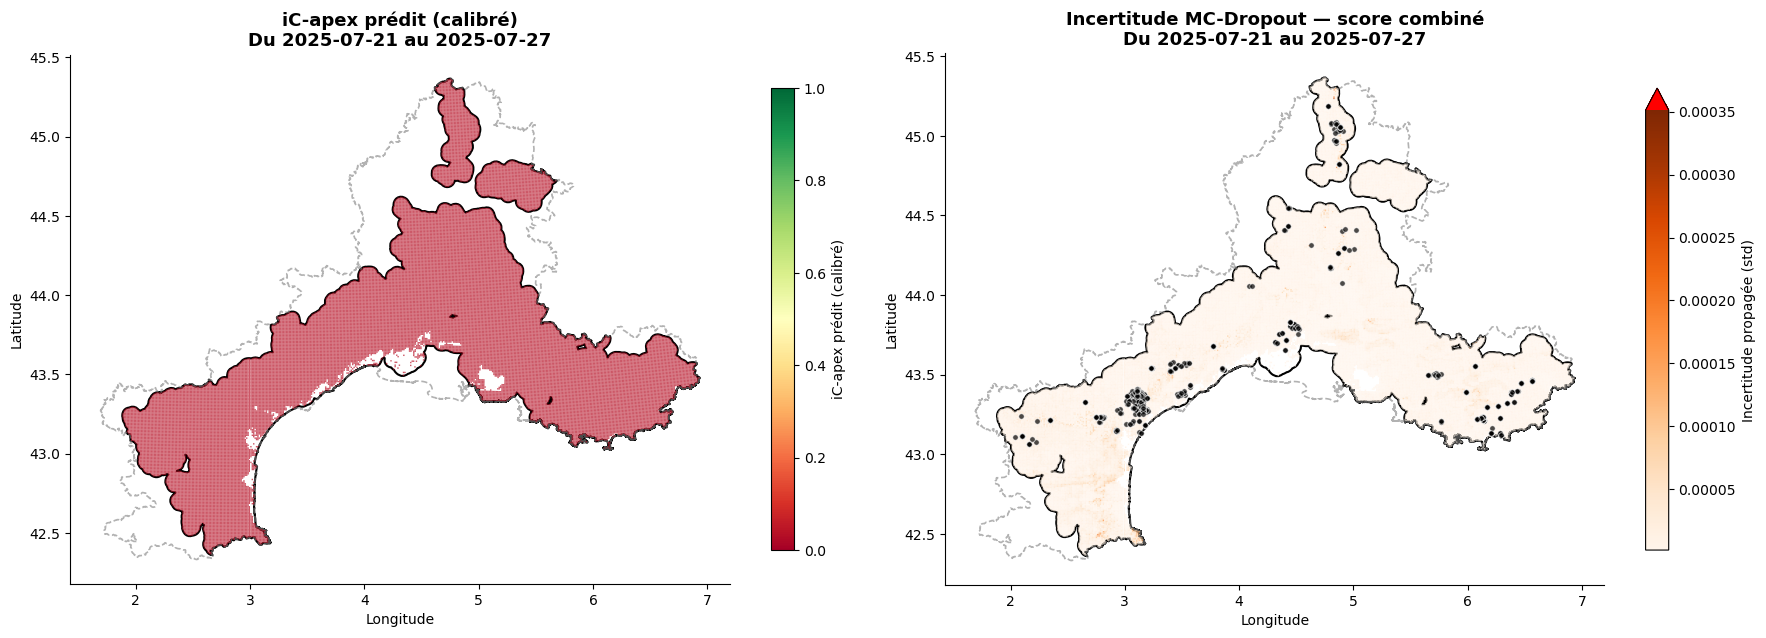

In [43]:
# --- Génération des 2 cartes (1 ligne x 2 colonnes) ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# ==============================================================
# Carte 1 : Score combiné p1*(1-p2)
# ==============================================================
ax1 = axes[0]
study_zone_wgs.plot(ax=ax1, facecolor='none', edgecolor='black', linewidth=1.5)
study_zone_bg_wgs.plot(ax=ax1, facecolor="none", edgecolor="grey", linewidth=1.2, linestyle="--", alpha=0.6)

if grid_pred['ic_apex_pred'].notna().any():
    grid_pred.dropna(subset=['ic_apex_pred']).plot(
        ax=ax1, column='ic_apex_pred', cmap='RdYlGn',
        vmin=0, vmax=1, legend=True, alpha=0.7,
        legend_kwds={'label': 'iC-apex prédit (calibré)', 'shrink': 0.6}
    )
    ax1.set_title(f'iC-apex prédit (calibré)\nDu {date_debut_str} au {date_fin_str}',
                  fontsize=13, fontweight='bold')
else:
    ax1.set_title(f'Carte calibrée non disponible\nDu {date_debut_str} au {date_fin_str}',
                  fontsize=13, fontweight='bold', color='gray')
    df_zone_wgs.plot(ax=ax1, column='ic_apex', cmap='RdYlGn', vmin=0, vmax=1,markersize=25, edgecolor='black', linewidth=0.8, alpha=0.9, legend=False)
    ax1.text(0.5, 0.5, 'ic_apex_pred indisponible\n(calibrateur pas encore généré)',
              ha='center', va='center', transform=ax1.transAxes, fontsize=10, color='gray')
# ==============================================================
# Carte 2 : Incertitude combinée
# ==============================================================
ax2 = axes[1]
study_zone_wgs.plot(ax=ax2, facecolor='none', edgecolor='black', linewidth=1.5)
study_zone_bg_wgs.plot(ax=ax2, facecolor="none", edgecolor="grey", linewidth=1.2, linestyle="--", alpha=0.6)
grid_pred.dropna(subset=['std_combined']).plot(
    ax=ax2, column='std_combined', cmap=cmap_incertitude,
    legend=True, alpha=0.7,
    legend_kwds={'label': 'Incertitude propagée (std)', 'shrink': 0.6, 'extend': 'max'}
)
df_zone_wgs.plot(
    ax=ax2, color='black',
    markersize=15, edgecolor='white', linewidth=0.5,
    alpha=0.7, legend=False
)
ax2.set_title(f'Incertitude MC-Dropout — score combiné\nDu {date_debut_str} au {date_fin_str}',
              fontsize=13, fontweight='bold')

# ==============================================================
# Finitions esthétiques
# ==============================================================
for ax in axes.flat:
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()

# --- Sauvegarde en PNG ---
from pathlib import Path
Path("results/cartes").mkdir(parents=True, exist_ok=True)
plt.savefig(f"results/cartes/{MODEL_TAG}_{date_debut_str}.png", dpi=150, bbox_inches='tight')

plt.show()

In [44]:
# code_dept_param = "34" 

# # Chargement et projection des départements en WGS84
# gdf_departements = gpd.read_file("data/contours_dpt.gpkg")
# gdf_deps_wgs84 = gdf_departements.to_crs("EPSG:4326")

# # Extraction du contour du département ciblé
# dept_cible = gdf_deps_wgs84[gdf_deps_wgs84["DDEP_C_COD"] == code_dept_param]

# if dept_cible.empty:
#     raise ValueError(f"Le département {code_dept_param} n'a pas été trouvé.")

# dept_nom = gdf_deps_wgs84.loc[gdf_deps_wgs84["DDEP_C_COD"] == code_dept_param, 'DDEP_L_LIB'].values[0]
# if code_dept_param in ["07","11","34"]:
#     dept_prep = "l'"
# elif code_dept_param in ["30", "83", "84"]:
#     dept_prep = "le "
# elif code_dept_param in ["13", "66"]:
#     dept_prep = "les "
# else:
#     dept_prep = "la "

# # Récupération de la préfecture du département ciblé
# ville_dept = villes_gdf[villes_gdf['Code_insee'] == code_dept_param]

# # Isolation de la géométrie du département
# dept_geom_only = dept_cible[['geometry']]

# # Découpe spatiale — 4 colonnes nécessaires
# print("Colonnes de grid_pred AVANT overlay :", grid_pred.columns.tolist())
# grid_pred_clipped  = gpd.overlay(grid_pred, dept_geom_only, how='intersection')
# print("Colonnes de grid_pred_clipped APRÈS overlay :", grid_pred_clipped.columns.tolist())
# df_zone_clipped    = gpd.overlay(df_zone_wgs, dept_geom_only, how='intersection')

# # Séparation des points terrain par classe
# df_presences_clipped = df_zone_clipped[df_zone_clipped['ic_apex'] >= 0.5]
# df_absences_clipped  = df_zone_clipped[df_zone_clipped['ic_apex'] <  0.5]

# # Colormap incertitude
# cmap_incertitude = plt.colormaps['Oranges'].copy()
# cmap_incertitude.set_over('red')

# # Légende commune
# legend_dpts = [
#     Line2D([0],[0], color="black", linewidth=1.5, linestyle="--", label="Département"),
#     Line2D([0],[0], color="grey",  linewidth=1,   linestyle="-",  label="Régions viticoles")
# ]

# # ==========================================
# # GÉNÉRATION DES 4 CARTES ZOOMÉES (2x2)
# # ==========================================
# fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# def plot_base(ax):
#     """Trace les éléments communs à toutes les cartes."""
#     study_zone_wgs.plot(ax=ax, facecolor='none', edgecolor='grey', linewidth=1)
#     dept_cible.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.5, linestyle='--', zorder=3)
#     if not ville_dept.empty:
#         ville_dept.plot(ax=ax, color='black', markersize=100, marker='.', edgecolor='black', linewidth=0.1, zorder=5)
#         for x, y, label in zip(ville_dept.geometry.x, ville_dept.geometry.y, ville_dept['Nom']):
#             ax.annotate(label, xy=(x, y), xytext=(4, 4),
#                         textcoords='offset points', fontsize=9,
#                         fontweight='bold', color='#2c3e50')

# # ==============================================================
# # LIGNE 1 : Classe iC-APEX <= 0.5
# # ==============================================================

# # --- Carte 1 : Score de <0.5 ---
# ax1 = axes[0, 0]
# plot_base(ax1)
# if not grid_pred_clipped.empty:
#     grid_pred_clipped.dropna(subset=['score_presence']).plot(
#         ax=ax1, column='score_presence', cmap='RdYlGn_r',
#         legend=True, alpha=0.7,
#         legend_kwds={'label': 'Probabilité observation > 0.5 (DeepMaxEnt)', 'shrink': 0.6}
#     )
# if not df_presences_clipped.empty:
#     df_presences_clipped.plot(
#         ax=ax1, column='ic_apex', cmap='RdYlGn_r',
#         markersize=35, edgecolor='black', linewidth=0.8,
#         alpha=0.9, legend=False, vmin=0, vmax=1, zorder=4
#     )
# ax1.set_title(f'Probabilité observation iC-APEX ≥ 0.5\n{dept_nom} ({code_dept_param}) | {date_debut_str} → {date_fin_str}',
#               fontsize=12, fontweight='bold')
# ax1.legend(handles=legend_dpts, fontsize=9, loc="upper right")

# # --- Carte 2 : Incertitude <0.5 ---
# ax2 = axes[0, 1]
# plot_base(ax2)
# if not grid_pred_clipped.empty:
#     grid_pred_clipped.dropna(subset=['std_presence']).plot(
#         ax=ax2, column='std_presence', cmap=cmap_incertitude,
#         legend=True, alpha=0.7,
#         legend_kwds={'label': 'Incertitude probabilité (std)', 'shrink': 0.6, 'extend': 'max'}
#     )
# if not df_presences_clipped.empty:
#     df_presences_clipped.plot(
#         ax=ax2, color='black',
#         markersize=20, edgecolor='white', linewidth=0.5,
#         alpha=0.7, legend=False, zorder=4
#     )
# ax2.set_title(f'Incertitude MC-Dropout — iC-APEX ≥ 0.5\n{dept_nom} ({code_dept_param}) | {date_debut_str} → {date_fin_str}',
#               fontsize=12, fontweight='bold')
# ax2.legend(handles=legend_dpts, fontsize=9, loc="upper right")

# # ==============================================================
# # LIGNE 2 : Classe iC-APEX > 0.5
# # ==============================================================

# # --- Carte 3 : Score d'absence ---
# ax3 = axes[1, 0]
# plot_base(ax3)
# if not grid_pred_clipped.empty:
#     grid_pred_clipped.dropna(subset=['score_absence']).plot(
#         ax=ax3, column='score_absence', cmap='RdYlGn_r',
#         legend=True, alpha=0.7,
#         legend_kwds={'label': 'Probabilité observation < 0.5 (DeepMaxEnt)', 'shrink': 0.6}
#     )
# if not df_absences_clipped.empty:
#     df_absences_clipped.plot(
#         ax=ax3, column='ic_apex', cmap='RdYlGn_r',
#         markersize=35, edgecolor='black', linewidth=0.8,
#         alpha=0.9, legend=False, vmin=0, vmax=1, zorder=4
#     )
# ax3.set_title(f'Probabilité observation iC-APEX < 0.5\n{dept_nom} ({code_dept_param}) | {date_debut_str} → {date_fin_str}',
#               fontsize=12, fontweight='bold')
# ax3.legend(handles=legend_dpts, fontsize=9, loc="upper right")

# # --- Carte 4 : Incertitude >0.5 ---
# ax4 = axes[1, 1]
# plot_base(ax4)
# if not grid_pred_clipped.empty:
#     grid_pred_clipped.dropna(subset=['std_absence']).plot(
#         ax=ax4, column='std_absence', cmap=cmap_incertitude,
#         legend=True, alpha=0.7,
#         legend_kwds={'label': 'Incertitude probabilité (std)', 'shrink': 0.6, 'extend': 'max'}
#     )
# if not df_absences_clipped.empty:
#     df_absences_clipped.plot(
#         ax=ax4, color='black',
#         markersize=20, edgecolor='white', linewidth=0.5,
#         alpha=0.7, legend=False, zorder=4
#     )
# ax4.set_title(f'Incertitude MC-Dropout — iC-APEX < 0.5\n{dept_nom} ({code_dept_param}) | {date_debut_str} → {date_fin_str}',
#               fontsize=12, fontweight='bold')
# ax4.legend(handles=legend_dpts, fontsize=9, loc="upper right")

# # ==============================================================
# # Finitions et zoom sur le département
# # ==============================================================
# bounds = dept_cible.total_bounds
# for ax in axes.flat:
#     ax.set_xlabel('Longitude')
#     ax.set_ylabel('Latitude')
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     ax.set_xlim(bounds[0] - 0.05, bounds[2] + 0.05)
#     ax.set_ylim(bounds[1] - 0.05, bounds[3] + 0.05)

# plt.tight_layout()
# plt.show()

In [45]:
# import matplotlib.pyplot as plt
# import numpy as np
# import torch
# from scipy.stats import kendalltau

# # ==============================================================================
# # 1. CALCUL DU KENDALL TAU PAR FOLD
# # ==============================================================================
# fold_taus = []
# for fold_data in all_results:
#     model_f  = fold_data["results"]["model"]
#     fold_idx = fold_data["fold"] - 1
#     X_val_raw    = x_vals[fold_idx]
#     y_val_f      = y_vals[fold_idx]
#     val_nan_mask = torch.isnan(X_val_raw).any(dim=1)
#     X_val_clean  = X_val_raw[~val_nan_mask]
#     y_val_clean  = y_val_f[~val_nan_mask]
#     if len(X_val_clean) == 0:
#         fold_taus.append((fold_data, float('nan')))
#         continue

#     X_val_cont_scaled = fold_data["scaler"].transform(X_val_clean[:, :n_continuous].numpy())
#     X_val_tensor_f    = torch.tensor(
#         np.concatenate([X_val_cont_scaled, X_val_clean[:, n_continuous:].numpy()], axis=1),
#         dtype=torch.float32
#     )
#     model_f.eval()
#     with torch.no_grad():
#         logits    = model_f(X_val_tensor_f.to(device))
#         val_preds = logits[:, 0].cpu().numpy()

#     val_true = (y_val_clean[:, 0] / (y_val_clean[:, 0] + y_val_clean[:, 1])).numpy()
#     tau, _ = kendalltau(val_true, val_preds)
#     fold_taus.append((fold_data, tau))

# # ==============================================================================
# # 2. SÉLECTION DES 3 MEILLEURS FOLDS (τ > 0.2), SI DISPONIBLES
# # ==============================================================================
# folds_valides = [(fd, tau) for fd, tau in fold_taus if not np.isnan(tau) and tau > 0.2]
# folds_valides.sort(key=lambda x: x[1], reverse=True)

# if len(folds_valides) < 3:
#     print(f"⚠️ Seulement {len(folds_valides)} fold(s) avec τ > 0.2 — condition non remplie (il en faut au moins 3).")
#     top_folds = []
# else:
#     top_folds = folds_valides[:3]
#     print("✅ Top 3 folds sélectionnés (Kendall τ) :")
#     for fd, tau in top_folds:
#         print(f"   Fold {fd['fold']:02d} — τ = {tau:.4f}")

# # ==============================================================================
# # 3. FONCTION : PRÉDICTION SUR TOUTE LA GRILLE POUR UN FOLD DONNÉ
# # ==============================================================================
# def predict_grid_for_fold(fold_data):
#     model = fold_data["results"]["model"]
#     scaler_grid = fold_data["scaler"]

#     valid_grid_mask = ~torch.isnan(X_tensor).any(dim=1)
#     X_grid_clean = X_tensor[valid_grid_mask]

#     X_grid_cont_scaled = scaler_grid.transform(X_grid_clean[:, :n_continuous].numpy())
#     X_grid_combined = np.concatenate([X_grid_cont_scaled, X_grid_clean[:, n_continuous:].numpy()], axis=1)
#     X_grid_final_tensor = torch.tensor(X_grid_combined, dtype=torch.float32)

#     mean_pred, std_pred, mean_presence, std_presence, mean_absence, std_absence = predict_with_uncertainty(
#         model=model,
#         X_tensor=X_grid_final_tensor,
#         device=device,
#         n_samples=100
#     )

#     pred_presence_full = torch.full((len(X_tensor),), float('nan'), dtype=torch.float32)
#     pred_absence_full  = torch.full((len(X_tensor),), float('nan'), dtype=torch.float32)
#     std_presence_full  = torch.full((len(X_tensor),), float('nan'), dtype=torch.float32)
#     std_absence_full   = torch.full((len(X_tensor),), float('nan'), dtype=torch.float32)

#     pred_presence_full[valid_grid_mask] = mean_presence
#     pred_absence_full[valid_grid_mask]  = mean_absence
#     std_presence_full[valid_grid_mask]  = std_presence
#     std_absence_full[valid_grid_mask]   = std_absence

#     return pred_presence_full, pred_absence_full, std_presence_full, std_absence_full

# # ==============================================================================
# # 4. FONCTION : CARTOGRAPHIE 2x2 POUR UN FOLD DONNÉ
# # ==============================================================================
# def plot_fold_maps(fold_data, tau, pred_presence_full, pred_absence_full,
#                     std_presence_full, std_absence_full):

#     grid_pred = grid_wgs.copy()
#     grid_pred['score_presence'] = pred_presence_full.numpy()
#     grid_pred['score_absence']  = pred_absence_full.numpy()
#     grid_pred['std_presence']   = std_presence_full.numpy()
#     grid_pred['std_absence']    = std_absence_full.numpy()

#     study_zone_wgs    = study_zone.to_crs("EPSG:4326")
#     study_zone_bg_wgs = study_zone_bg.to_crs("EPSG:4326")
#     df_zone_wgs       = df_zone.to_crs("EPSG:4326").copy()

#     df_presences = df_zone_wgs[df_zone_wgs['ic_apex'] >= 0.5]
#     df_absences  = df_zone_wgs[df_zone_wgs['ic_apex'] <  0.5]

#     cmap_incertitude = plt.colormaps['Oranges'].copy()
#     cmap_incertitude.set_over('red')

#     fig, axes = plt.subplots(2, 2, figsize=(18, 16))
#     fold_num = fold_data['fold']

#     # --- Carte 1 : Score >= 0.5 ---
#     ax1 = axes[0, 0]
#     study_zone_wgs.plot(ax=ax1, facecolor='none', edgecolor='black', linewidth=1.5)
#     study_zone_bg_wgs.plot(ax=ax1, facecolor="none", edgecolor="grey", linewidth=1.2, linestyle="--", alpha=0.6)
#     grid_pred.dropna(subset=['score_presence']).plot(
#         ax=ax1, column='score_presence', cmap='RdYlGn_r',
#         legend=True, alpha=0.7,
#         legend_kwds={'label': 'Probabilité observation > 0.5 (DeepMaxEnt)', 'shrink': 0.6}
#     )
#     df_presences.plot(
#         ax=ax1, column='ic_apex', cmap='RdYlGn_r',
#         markersize=25, edgecolor='black', linewidth=0.8,
#         alpha=0.9, legend=False, vmin=0, vmax=1
#     )
#     ax1.set_title(f'Fold {fold_num} (τ={tau:.3f}) — Probabilité iC-APEX ≥ 0.5\nDu {date_debut_str} au {date_fin_str}',
#                   fontsize=13, fontweight='bold')

#     # --- Carte 2 : Incertitude >= 0.5 ---
#     ax2 = axes[0, 1]
#     study_zone_wgs.plot(ax=ax2, facecolor='none', edgecolor='black', linewidth=1.5)
#     study_zone_bg_wgs.plot(ax=ax2, facecolor="none", edgecolor="grey", linewidth=1.2, linestyle="--", alpha=0.6)
#     grid_pred.dropna(subset=['std_presence']).plot(
#         ax=ax2, column='std_presence', cmap=cmap_incertitude,
#         legend=True, alpha=0.7,
#         legend_kwds={'label': 'Incertitude probabilité (std)', 'shrink': 0.6, 'extend': 'max'}
#     )
#     df_presences.plot(
#         ax=ax2, color='black',
#         markersize=15, edgecolor='white', linewidth=0.5,
#         alpha=0.7, legend=False
#     )
#     ax2.set_title(f'Fold {fold_num} (τ={tau:.3f}) — Incertitude MC-Dropout ≥ 0.5\nDu {date_debut_str} au {date_fin_str}',
#                   fontsize=13, fontweight='bold')

#     # --- Carte 3 : Score < 0.5 ---
#     ax3 = axes[1, 0]
#     study_zone_wgs.plot(ax=ax3, facecolor='none', edgecolor='black', linewidth=1.5)
#     study_zone_bg_wgs.plot(ax=ax3, facecolor="none", edgecolor="grey", linewidth=1.2, linestyle="--", alpha=0.6)
#     grid_pred.dropna(subset=['score_absence']).plot(
#         ax=ax3, column='score_absence', cmap='RdYlGn_r',
#         legend=True, alpha=0.7,
#         legend_kwds={'label': 'Probabilité observation < 0.5 (DeepMaxEnt)', 'shrink': 0.6}
#     )
#     df_absences.plot(
#         ax=ax3, column='ic_apex', cmap='RdYlGn_r',
#         markersize=25, edgecolor='black', linewidth=0.8,
#         alpha=0.9, legend=False, vmin=0, vmax=1
#     )
#     ax3.set_title(f'Fold {fold_num} (τ={tau:.3f}) — Probabilité iC-APEX < 0.5\nDu {date_debut_str} au {date_fin_str}',
#                   fontsize=13, fontweight='bold')

#     # --- Carte 4 : Incertitude < 0.5 ---
#     ax4 = axes[1, 1]
#     study_zone_wgs.plot(ax=ax4, facecolor='none', edgecolor='black', linewidth=1.5)
#     study_zone_bg_wgs.plot(ax=ax4, facecolor="none", edgecolor="grey", linewidth=1.2, linestyle="--", alpha=0.6)
#     grid_pred.dropna(subset=['std_absence']).plot(
#         ax=ax4, column='std_absence', cmap=cmap_incertitude,
#         legend=True, alpha=0.7,
#         legend_kwds={'label': 'Incertitude probabilité (std)', 'shrink': 0.6, 'extend': 'max'}
#     )
#     df_absences.plot(
#         ax=ax4, color='black',
#         markersize=15, edgecolor='white', linewidth=0.5,
#         alpha=0.7, legend=False
#     )
#     ax4.set_title(f'Fold {fold_num} (τ={tau:.3f}) — Incertitude MC-Dropout < 0.5\nDu {date_debut_str} au {date_fin_str}',
#                   fontsize=13, fontweight='bold')

#     for ax in axes.flat:
#         ax.set_xlabel('Longitude')
#         ax.set_ylabel('Latitude')
#         ax.spines['top'].set_visible(False)
#         ax.spines['right'].set_visible(False)

#     plt.tight_layout()
#     plt.show()

# # ==============================================================================
# # 5. EXÉCUTION : PRÉDICTION + CARTOGRAPHIE POUR CHAQUE FOLD SÉLECTIONNÉ
# # ==============================================================================
# for fold_data, tau in top_folds:
#     print(f"\n🚀 Traitement du Fold {fold_data['fold']:02d} (τ = {tau:.4f})...")
#     pred_presence_full, pred_absence_full, std_presence_full, std_absence_full = predict_grid_for_fold(fold_data)
#     plot_fold_maps(fold_data, tau, pred_presence_full, pred_absence_full, std_presence_full, std_absence_full)

In [46]:
# ==============================================================================
# RÉSUMÉ TABULÉ : Nb d'observations, nb de cellules observées et Kendall tau par fold
# ==============================================================================
import pandas as pd
from scipy.stats import kendalltau

nb_observations = len(df_zone_wgs)
nb_cellules     = observed_mask.sum().item()

summary_rows = []

for fold_data in all_results:
    fold_idx = fold_data["fold"] - 1

    X_val_raw = x_vals[fold_idx]
    y_val_f   = y_vals[fold_idx]
    val_nan_mask = torch.isnan(X_val_raw).any(dim=1)
    X_val_clean  = X_val_raw[~val_nan_mask]
    y_val_clean  = y_val_f[~val_nan_mask]

    if len(X_val_clean) == 0:
        summary_rows.append({
            "Fold": fold_data["fold"],
            "Nb observations": nb_observations,
            "Nb cellules observées": nb_cellules,
            "Kendall tau": float("nan")
        })
        continue

    X_val_cont_scaled = fold_data["scaler"].transform(X_val_clean[:, :n_continuous].numpy())
    X_val_tensor_f = torch.tensor(
        np.concatenate([X_val_cont_scaled, X_val_clean[:, n_continuous:].numpy()], axis=1),
        dtype=torch.float32
    )
    model_f = fold_data["results"]["model"]
    model_f.eval()
    with torch.no_grad():
        logits = model_f(X_val_tensor_f.to(device))
        val_preds = logits[:, 0].cpu().numpy()

    val_true = (y_val_clean[:, 0] / (y_val_clean[:, 0] + y_val_clean[:, 1])).numpy()
    tau, _ = kendalltau(val_true, val_preds)

    summary_rows.append({
        "Fold": fold_data["fold"],
        "Nb observations": nb_observations,
        "Nb cellules observées": nb_cellules,
        "Kendall tau": round(tau, 4)
    })

df_summary = pd.DataFrame(summary_rows).set_index("Fold")

valid_taus = df_summary["Kendall tau"].dropna()
print(f"Kendall tau moyen : {valid_taus.mean():.4f} ± {valid_taus.std():.4f}  (sur {len(valid_taus)} folds)")

df_summary

Kendall tau moyen : 0.1943 ± 0.1571  (sur 10 folds)


,Nb observations,Nb cellules observées,Kendall tau
Fold,,,
1,751,229,-0.0152
2,751,229,0.1603
3,751,229,-0.0463
4,751,229,0.4556
5,751,229,0.2126
6,751,229,0.3440
7,751,229,0.1836
8,751,229,0.3240
9,751,229,0.0948


In [47]:
# ==============================================================================
# RÉSUMÉ TABULÉ : Nb d'observations, nb de cellules observées, Kendall tau, AUC-ROC
# et Balanced Accuracy par fold — on ne garde que les 3 meilleurs folds (Kendall tau)
# ==============================================================================
import pandas as pd
import numpy as np
from scipy.stats import kendalltau
from sklearn.metrics import roc_auc_score

nb_observations = len(df_zone_wgs)
nb_cellules     = observed_mask.sum().item()
summary_rows = []
all_val_true = []

for fold_data in all_results:
    fold_idx = fold_data["fold"] - 1
    X_val_raw = x_vals[fold_idx]
    y_val_f   = y_vals[fold_idx]
    val_nan_mask = torch.isnan(X_val_raw).any(dim=1)
    X_val_clean  = X_val_raw[~val_nan_mask]
    y_val_clean  = y_val_f[~val_nan_mask]

    if len(X_val_clean) == 0:
        summary_rows.append({
            "Fold": fold_data["fold"],
            "Nb observations": nb_observations,
            "Nb cellules observées": nb_cellules,
            "Kendall tau": float("nan"),
            "AUC-ROC": float("nan")
        })
        continue

    X_val_cont_scaled = fold_data["scaler"].transform(X_val_clean[:, :n_continuous].numpy())
    X_val_tensor_f = torch.tensor(
        np.concatenate([X_val_cont_scaled, X_val_clean[:, n_continuous:].numpy()], axis=1),
        dtype=torch.float32
    )
    model_f = fold_data["results"]["model"]
    model_f.eval()
    with torch.no_grad():
        logits = model_f(X_val_tensor_f.to(device))
        val_preds = logits[:, 0].cpu().numpy()

    val_true = (y_val_clean[:, 0] / (y_val_clean[:, 0] + y_val_clean[:, 1])).numpy()
    all_val_true.append(val_true)
    tau, _ = kendalltau(val_true, val_preds)

    # Binarisation pour l'AUC-ROC et la Balanced Accuracy (même seuil que dans le reste du notebook)
    val_true_binary = (val_true >= 0.5).astype(int)

    if len(np.unique(val_true_binary)) > 1:
        auc = roc_auc_score(val_true_binary, val_preds)
    else:
        auc = float("nan")  # AUC indéfinie si une seule classe présente dans le fold

    summary_rows.append({
        "Fold": fold_data["fold"],
        "Nb observations": nb_observations,
        "Nb cellules observées": nb_cellules,
        "Kendall tau": round(tau, 4),
        "AUC-ROC": round(auc, 4) if not np.isnan(auc) else float("nan")
    })

df_summary = pd.DataFrame(summary_rows).set_index("Fold")

# --- Sélection des 3 meilleurs folds selon le Kendall tau (moins si pas assez disponibles) ---
# na_position="last" : un fold à Kendall tau NaN n'est gardé que s'il ne reste pas
# assez de folds valides pour compléter le top 3.
N_BEST_FOLDS = 3
df_summary = df_summary.sort_values("Kendall tau", ascending=False, na_position="last").head(N_BEST_FOLDS)

valid_taus     = df_summary["Kendall tau"].dropna()
valid_aucs     = df_summary["AUC-ROC"].dropna()

print(f"Kendall tau moyen        : {valid_taus.mean():.4f} ± {valid_taus.std():.4f}  (sur {len(valid_taus)} folds)")
print(f"AUC-ROC moyen            : {valid_aucs.mean():.4f} ± {valid_aucs.std():.4f}  (sur {len(valid_aucs)} folds)")

df_summary

Kendall tau moyen        : 0.3745 ± 0.0709  (sur 3 folds)
AUC-ROC moyen            : 0.7784 ± 0.0511  (sur 3 folds)


,Nb observations,Nb cellules observées,Kendall tau,AUC-ROC
Fold,,,,
4,751,229,0.4556,0.8333
6,751,229,0.3440,0.7698
8,751,229,0.3240,0.7321


In [48]:
import pickle
import numpy as np
from pathlib import Path

val_true_concat = np.concatenate(all_val_true) if all_val_true else np.array([])
ic_apex_moy = float(val_true_concat.mean()) if len(val_true_concat) else float("nan")
std_ic_apex = float(val_true_concat.std())  if len(val_true_concat) else float("nan")

export_data = {
    "date_debut_str": date_debut_str,
    "df_summary": df_summary,
    "ic_apex_moy": ic_apex_moy,
    "std_ic_apex": std_ic_apex,
    "oof_score_combined": oof_score_combined,
    "oof_std_combined": oof_std_combined,
    "oof_ic_apex_true": oof_ic_apex_true,
}

Path("results").mkdir(exist_ok=True)
with open(f"results/{MODEL_TAG}_{date_debut_str}.pkl", "wb") as f:
    pickle.dump(export_data, f)

print(f"✅ Résultats exportés : results/{MODEL_TAG}_{date_debut_str}.pkl")

✅ Résultats exportés : results/degrade_2025-07-21.pkl
